# Customer Segmentation Analysis — Online Retail Dataset
### Unsupervised Machine Learning for Customer Segmentation & Targeted Marketing Strategy

**Team Members:** *(add full names & IDs)*
1. Member 1 — Role:
2. Member 2 — Role:
3. Member 3 — Role:
4. Member 4 — Role:

**Course / Program:** *Business Analytics*
**Submission Date:** *(add date)*
**Dataset:** OnlineRetail_messy.xlsx (541,959 transactions, UK-based online retailer, Dec 2010 – Dec 2011)

---

## Project Overview

This notebook documents the full workflow for segmenting customers of an online retail business using
unsupervised machine learning, based on purchasing behavior (Recency, Frequency, Monetary value).
The goal is to support **targeted marketing, personalized recommendations, revenue optimization, and churn prevention**.

**Notebook structure:**

| Section | Content |
|---|---|
| 1 | Setup & Data Loading |
| 2 | Initial Data Inspection |
| 3 | Data Cleaning |
| 4 | Exploratory Data Analysis (EDA) |
| 5 | RFM Feature Engineering |
| 6 | Feature Scaling & Preparation for Clustering |
| 7 | K-Means Clustering (optimal k selection) |
| 8 | Alternative Clustering Algorithms (Hierarchical, DBSCAN, GMM) |
| 9 | Interactive Cluster Visualization (Plotly) |
| 10 | Cluster/Segment Profiling |
| 11 | Segment Naming & Business Strategy |
| 12 | Customer Lifetime Value (CLV) — bonus |
| 13 | Final Conclusions & Business Recommendations |

> **Note to team:** Every section below has a short markdown brief explaining *what* to do and *why*, followed by an
> empty code cell for the implementation, and (where relevant) a **"📝 Findings"** markdown cell for you to fill in
> your numbers, charts takeaways, and interpretation. Please do not delete the brief/instructions — keep them as
> documentation for the reader/grader.


## Project Methodology — CRISP-DM

This notebook follows **CRISP-DM (Cross-Industry Standard Process for Data Mining)**, the standard six-phase
methodology for data mining/ML projects. CRISP-DM phases are not strictly linear — it's normal to revisit an
earlier phase (e.g. going back to Data Understanding after an initial cleaning pass), and this notebook does
that once, flagged clearly where it happens.

| Phase | What it covers in this project |
|---|---|
| 1. Business Understanding | Segmentation goals, success criteria, project scope |
| 2. Data Understanding | Initial inspection of `OnlineRetail_messy.xlsx`, and EDA once cleaned |
| 3. Data Preparation | Data cleaning (Steps 1–12), RFM feature engineering, scaling |
| 4. Modeling | K-Means clustering + alternative algorithms (Hierarchical, DBSCAN, GMM) |
| 5. Evaluation | Cluster visualization, segment profiling, naming, CLV — checked against business goals |
| 6. Deployment | Final recommendations, limitations, and next steps for the business |

---
# Phase 1: Business Understanding

**Business objective:** segment customers of the online retail business based on purchasing behavior (RFM),
to support targeted marketing, revenue optimization, personalized recommendations, and churn prevention.

**Data mining goal:** produce 4–5 distinct, statistically-validated customer segments using unsupervised
clustering (K-Means, cross-checked against at least one alternative algorithm), each with a clear behavioral
profile the marketing team can act on.

**Success criteria:**
- Silhouette Score ≥ 0.50 for the chosen clustering solution (or a documented, justified reason if lower)
- Every segment has a business-interpretable name and at least one concrete recommended action
- Deliverables: cleaned dataset, this notebook, and a short business-facing summary of findings

> 🔧 **To be finalized by the team:** exact success-criteria numbers above, team member names/roles, and the
> submission date in the title cell — update once agreed as the project progresses.


---
# 1. Setup & Data Loading

**Goal:** Import required libraries and load the raw transaction dataset (`OnlineRetail_messy.xlsx`).

**What to include:**
- Core libraries: `pandas`, `numpy`
- Visualization: `matplotlib`, `seaborn` for static EDA charts, and **`plotly`** (`plotly.express` / `plotly.graph_objects`) for
  interactive cluster and business visuals later in the notebook
- Modeling: `scikit-learn` (StandardScaler, KMeans, AgglomerativeClustering, DBSCAN, GaussianMixture, metrics)
- Set a consistent plotting style and `random_state` (use `42` everywhere for reproducibility across the team)
- Load the Excel file into a DataFrame called `df`

**Deliverable of this section:** a single DataFrame `df` loaded and ready for inspection.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
RANDOM_STATE = 42
plt.rcParams['figure.figsize'] = (10, 5)
print("Libraries loaded.")

Libraries loaded.


In [ ]:
df = pd.read_excel('../data/OnlineRetail_messy.xlsx')#data loaded
print("Raw shape:", df.shape)
df.isnull().sum()

Raw shape: (541959, 8)


,0
InvoiceNo,27098
StockCode,0
Description,28465
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,155414
Country,0


---
# Phase 2: Data Understanding

**Goal (CRISP-DM tasks):** collect the initial dataset, describe its structure, and identify data quality
issues before any cleaning is attempted — this sets the baseline for every decision made in Data Preparation.


---
# 2. Initial Data Inspection

**Goal:** Understand the raw structure of the data before touching it.

**What to check:**
- Shape (rows x columns)
- Column data types (`.info()`)
- First/last rows (`.head()`, `.tail()`)
- Summary statistics (`.describe()`) — look closely at `Quantity` and `UnitPrice` min/max (expect negative values)
- Missing values per column (`.isnull().sum()`)
- Number of duplicate rows (`.duplicated().sum()`)
- Unique counts for `InvoiceNo`, `StockCode`, `CustomerID`, `Country`

**Reference point:** the dataset documentation (OnlineRetail.pdf) reports ~541,959 rows, 8 columns, ~25.19%+
missing `CustomerID`, missing `Description`, and ~50 intentionally duplicated rows plus ~80 intentional outliers —
your numbers should be in the same ballpark (the messy file has extra corruption beyond the raw original).


In [ ]:
# Shape, dtypes, head/tail
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nHead Rows:")
print(df.head())

print("\nTail Rows:")
print(df.tail())

Shape: (541959, 8)

Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

Missing Values:
InvoiceNo       27098
StockCode           0
Description     28465
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     155414
Country             0
dtype: int64

Head Rows:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    8402

In [ ]:
# Descriptive statistics (df.describe())
print("\nDescriptive Statistics:")
print(df.describe())


Descriptive Statistics:
            Quantity                    InvoiceDate      UnitPrice  \
count  541959.000000                         541959  541959.000000   
mean        0.325558  2011-07-04 13:34:37.842825472       4.057307   
min   -100000.000000            2010-12-01 08:26:00  -11062.060000   
25%         1.000000            2011-03-28 11:34:00       1.250000   
50%         3.000000            2011-07-19 17:17:00       2.080000   
75%        10.000000            2011-10-19 11:27:00       4.130000   
max     80995.000000            2011-12-09 12:50:00   38970.000000   
std       985.000935                            NaN     122.073297   

          CustomerID  
count  386545.000000  
mean    15287.336088  
min     12346.000000  
25%     13953.000000  
50%     15152.000000  
75%     16791.000000  
max     18287.000000  
std      1713.191360  


In [ ]:
# Standardize Column Names
df.columns = df.columns.str.strip()
df.columns

#Strip Text Columns
text_columns = ["InvoiceNo", "StockCode", "Description", "Country"]

for col in text_columns:
    df[col] = df[col].astype("string").str.strip()

In [ ]:
# Duplicate rows count
print("\nDuplicate Rows:")
print(df.duplicated().sum())


Duplicate Rows:
4015


### 📝 Findings — Initial Inspection

- **Total rows / columns:** 541,959 rows × 8 columns
- **Columns with missing values:**
  - CustomerID — 155,414 (28.68%)
  - Description — 28,465 (5.25%)
  - InvoiceNo — 27,098 (5.00%)
  - (StockCode, Quantity, InvoiceDate, UnitPrice, Country — 0% missing)
- **Duplicate rows found:** 4,790 exact duplicates
- **Unexpected values:**
  - `Quantity` min = **-100,000** (later confirmed as an injected sentinel outlier, not a real return)
  - `UnitPrice` min = **-11,062.06**, max = **38,970.00** (extreme negative/positive values needing investigation)
  - `InvoiceDate` already loads as proper `datetime64`, no conversion issue at this stage
  - `CustomerID` loads as `float64` (expected, due to missing values) — will convert to `int` after recovery/cleaning

---
# Phase 3: Data Preparation

**Goal (CRISP-DM tasks):** select, clean, and construct the final dataset used for modeling. This is typically
the most time-consuming phase of a data mining project, and it is here, since evidence-based recovery (not
blanket deletion) is used for every recoverable missing value — see the step-by-step breakdown below.


---
# 3. Data Cleaning

**Goal:** Turn the raw, messy transaction log into a trustworthy dataset ready for analysis and modeling.
Follow this order — each step depends on the one before it:

1. **Handle missing `CustomerID`** — decide: drop rows without a customer id (needed for segmentation, since we can't
   assign a cluster to an unknown customer) vs. keep them tagged as "guest" for product-level analysis only.
   *Recommendation: drop for the RFM/clustering pipeline.*
2. **Handle missing `Description`** — fill with `"UNKNOWN"` or drop if row also has no useful info.
3. **Separate returns/cancellations from purchases** — `Quantity < 0` = returns. Keep them for a separate returns
   analysis, but exclude from the main purchases table used for revenue/RFM.
4. **Remove/flag invalid prices** — `UnitPrice <= 0` should not be counted as real revenue.
5. **Remove suspicious/extreme values** — extreme bulk orders or freak prices that look like data entry errors
   (define and justify your own thresholds; document them here).
6. **Clean `Description` text** — strip whitespace, remove test/placeholder entries (e.g. "TEST", "SAMPLE", "DAMAGED").
7. **Validate dates** — convert `InvoiceDate` to datetime, drop rows outside a sensible range (e.g. before 2000 or
   in the future).
8. **Standardize `Country` names** — fix inconsistent labels (e.g. "EIRE" → "Ireland"), strip blanks.
9. **Remove exact duplicate transactions** — duplicated on `CustomerID` + `InvoiceNo` + `StockCode`.
10. **Create `TransactionAmount` = Quantity × UnitPrice`** and run a final validation checklist confirming: no
    missing CustomerID, all positive quantities/prices/revenue, valid date range, no duplicates.

**Important:** keep the raw `df` untouched and build a cleaned copy (e.g. `df_clean` / `df_purchases`) so you can
always go back and compare before/after.


## Step 1 - Recover missing `CustomerID` using `InvoiceNo`

**Logic:** In real retail data, all line items on the same invoice belong to the same customer. So if an
`InvoiceNo` appears elsewhere in the dataset with a known `CustomerID`, and **that InvoiceNo is associated with
exactly one unique CustomerID**, we can safely fill in the missing `CustomerID` for other rows sharing that same
invoice. If an `InvoiceNo` maps to more than one distinct `CustomerID` (a data quality problem in its own right),
we treat it as ambiguous and do not guess.

In [ ]:
# Build InvoiceNo -> CustomerID map using only rows where CustomerID is already known
invoice_customer_nunique = (
    df.dropna(subset=['CustomerID'])
      .groupby('InvoiceNo')['CustomerID']
      .nunique()
)

# Keep only invoices that map to exactly ONE unique CustomerID (safe to use)
safe_invoices = invoice_customer_nunique[invoice_customer_nunique == 1].index
ambiguous_invoices = invoice_customer_nunique[invoice_customer_nunique > 1].index

invoice_to_customer = (
    df.dropna(subset=['CustomerID'])
      .groupby('InvoiceNo')['CustomerID']
      .first()
      .loc[safe_invoices]
)

print(f"Invoices with a single unique CustomerID (safe to use): {len(safe_invoices)}")
print(f"Invoices with multiple different CustomerIDs (ambiguous, skipped): {len(ambiguous_invoices)}")

Invoices with a single unique CustomerID (safe to use): 21847
Invoices with multiple different CustomerIDs (ambiguous, skipped): 0


In [ ]:
before_missing = df['CustomerID'].isnull().sum()

missing_customer_mask = df['CustomerID'].isnull()
recoverable_mask = missing_customer_mask & df['InvoiceNo'].isin(invoice_to_customer.index)

df.loc[recoverable_mask, 'CustomerID'] = df.loc[recoverable_mask, 'InvoiceNo'].map(invoice_to_customer)

after_missing = df['CustomerID'].isnull().sum()
print(f"Missing CustomerID before recovery: {before_missing}")
print(f"Recovered using InvoiceNo relationship: {before_missing - after_missing}")
print(f"Still missing (InvoiceNo also missing, or InvoiceNo is ambiguous): {after_missing}")

# NOTE: unlike an earlier version, df is NOT split into known/unknown-CustomerID here anymore.
# All rows (including still-missing CustomerID) stay together in `df` and go through the same
# cleaning steps (7-12) -- the actual Purchases / Returns / Guests split now happens in Step 13,
# once every row has been through identical cleaning.

Missing CustomerID before recovery: 155414
Recovered using InvoiceNo relationship: 19156
Still missing (InvoiceNo also missing, or InvoiceNo is ambiguous): 136258


**Result on this dataset:** 19,156 `CustomerID` values were recovered this way -- these are not guesses,
they follow directly from the one-invoice-one-customer relationship in the data. The remaining missing
`CustomerID` values are true unknowns (guest/unregistered-style transactions, or rows whose `InvoiceNo` is also
missing) and will be excluded from the RFM dataset later, not imputed.

## Step 2 - Recover missing `InvoiceNo` using `CustomerID` + `InvoiceDate`

**Logic:** `InvoiceDate` in this dataset includes a timestamp down to the minute (verified below), not just a
date -- so a `(CustomerID, InvoiceDate)` pair is a strong candidate key for identifying a specific transaction.
If that pair maps to exactly one unique `InvoiceNo` elsewhere in the data, we use it to fill the missing value.
If the same customer has multiple different invoices at that exact timestamp (rare, but possible), we leave it
missing rather than guess.

This step runs **after** Step 1 on purpose -- recovering `CustomerID` first means more rows now have a usable
key for this step.

In [ ]:
# Confirm InvoiceDate has time-level granularity (not just dates) -- this justifies using it as part of a key
has_time_component = (df['InvoiceDate'].dt.time != pd.Timestamp('00:00:00').time()).any()
print("InvoiceDate includes time-of-day (not just date):", has_time_component)

InvoiceDate includes time-of-day (not just date): True


In [ ]:
known_pairs = df.dropna(subset=['InvoiceNo', 'CustomerID'])

pair_nunique = known_pairs.groupby(['CustomerID', 'InvoiceDate'])['InvoiceNo'].nunique()
safe_pairs_index = pair_nunique[pair_nunique == 1].index

pair_to_invoice = (
    known_pairs.groupby(['CustomerID', 'InvoiceDate'])['InvoiceNo']
    .first()
)
pair_to_invoice = pair_to_invoice.loc[pair_to_invoice.index.isin(safe_pairs_index)]

print(f"(CustomerID, InvoiceDate) pairs with a single unique InvoiceNo (safe): {len(safe_pairs_index)}")
print(f"Ambiguous pairs (multiple InvoiceNos at same timestamp): {(pair_nunique > 1).sum()}")

(CustomerID, InvoiceDate) pairs with a single unique InvoiceNo (safe): 21534
Ambiguous pairs (multiple InvoiceNos at same timestamp): 172


In [ ]:
before_missing_inv = df['InvoiceNo'].isnull().sum()

missing_invoice_mask = df['InvoiceNo'].isnull()
keys = pd.Series(list(zip(df['CustomerID'], df['InvoiceDate'])), index=df.index)
recoverable_inv_mask = missing_invoice_mask & keys.isin(pair_to_invoice.index)

df.loc[recoverable_inv_mask, 'InvoiceNo'] = [
    pair_to_invoice.get((cust, date))
    for cust, date in zip(df.loc[recoverable_inv_mask, 'CustomerID'], df.loc[recoverable_inv_mask, 'InvoiceDate'])
]

after_missing_inv = df['InvoiceNo'].isnull().sum()
print(f"Missing InvoiceNo before recovery: {before_missing_inv}")
print(f"Recovered using CustomerID+InvoiceDate relationship: {before_missing_inv - after_missing_inv}")
print(f"Still missing (CustomerID also unknown, or pair is ambiguous): {after_missing_inv}")

Missing InvoiceNo before recovery: 27098
Recovered using CustomerID+InvoiceDate relationship: 18870
Still missing (CustomerID also unknown, or pair is ambiguous): 8228


**Result on this dataset:** 18,870 `InvoiceNo` values were recovered. The remaining missing values are
rows where `CustomerID` is still unknown (so there's no key to look up) or where the `(CustomerID, InvoiceDate)`
pair is genuinely ambiguous.

## Step 3 - Validate `StockCode`

We check programmatically rather than assuming -- if `StockCode` did have missing values, it would need its own
recovery or exclusion strategy (there's no reliable column to recover a product ID from).

In [ ]:
stockcode_missing = df['StockCode'].isnull().sum()
print(f"Missing StockCode: {stockcode_missing}")

if stockcode_missing == 0:
    print("Confirmed: StockCode has no missing values in this dataset -- no imputation needed.")
else:
    print("StockCode has missing values -- flag for team review before proceeding "
          "(no reliable recovery relationship exists for a product identifier).")

Missing StockCode: 0
Confirmed: StockCode has no missing values in this dataset -- no imputation needed.


## Step 4 - Recover missing `Description` using `StockCode`

**Logic:** the same `StockCode` should refer to the same product, so it should have one consistent
`Description`. If a `StockCode` has exactly one distinct non-null `Description` elsewhere in the data, we use it
to fill missing values. If a `StockCode` has genuinely different descriptions on file (e.g. renamed products,
typos treated as distinct strings), we leave those missing rather than pick one arbitrarily.

Per the project's own scope, `Description` is not required for RFM/K-Means, so we do **not** drop transactions
just because `Description` is missing -- losing a real transaction from the revenue/frequency picture would be a
worse outcome than an unlabeled product name.

In [ ]:
desc_lookup = df.dropna(subset=['Description']).copy()
desc_lookup['Description'] = desc_lookup['Description'].str.strip()

stockcode_desc_nunique = desc_lookup.groupby('StockCode')['Description'].nunique()
safe_stockcodes = stockcode_desc_nunique[stockcode_desc_nunique == 1].index
ambiguous_stockcodes = stockcode_desc_nunique[stockcode_desc_nunique > 1].index

stockcode_to_desc = (
    desc_lookup[desc_lookup['StockCode'].isin(safe_stockcodes)]
    .groupby('StockCode')['Description']
    .first()
)

print(f"StockCodes with one consistent Description (safe to use): {len(safe_stockcodes)}")
print(f"StockCodes with multiple different Descriptions (ambiguous, skipped): {len(ambiguous_stockcodes)}")

StockCodes with one consistent Description (safe to use): 3320
StockCodes with multiple different Descriptions (ambiguous, skipped): 628


In [ ]:
before_missing_desc = df['Description'].isnull().sum()

missing_desc_mask = df['Description'].isnull()
recoverable_desc_mask = missing_desc_mask & df['StockCode'].isin(stockcode_to_desc.index)

df.loc[recoverable_desc_mask, 'Description'] = df.loc[recoverable_desc_mask, 'StockCode'].map(stockcode_to_desc)

after_missing_desc = df['Description'].isnull().sum()
print(f"Missing Description before recovery: {before_missing_desc}")
print(f"Recovered using StockCode relationship: {before_missing_desc - after_missing_desc}")
print(f"Still missing (StockCode ambiguous or itself unusual): {after_missing_desc}")

Missing Description before recovery: 28465
Recovered using StockCode relationship: 22506
Still missing (StockCode ambiguous or itself unusual): 5959


**Result on this dataset:** 22,506 `Description` values were recovered from unambiguous `StockCode`s;
628 `StockCode`s had genuinely ambiguous multiple descriptions on file (left untouched, not guessed). The
remaining ~5,959 missing descriptions are kept as `NaN` -- rows are **not** dropped for this reason.

## Step 5 - Data types & whitespace

Convert `InvoiceDate` to a real datetime type, and strip stray whitespace from string columns -- carefully,
so that actual missing values stay as `NaN`/`NA` and are never accidentally converted into the *string*
`"nan"` or `"None"`.

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

string_cols = ['InvoiceNo', 'StockCode', 'Description', 'Country']
for col in string_cols:
    # Only strip actual strings -- leave NaN as NaN, don't call .str on the whole column
    df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)

print(df.dtypes)
print()
print("Any missing values turned into the literal string 'nan'/'None'?",
      bool(df[string_cols].isin(['nan', 'None', 'NaN', 'NAN']).any().any()))

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

Any missing values turned into the literal string 'nan'/'None'? False


## Step 6 - Standardize `Country` labels

In [ ]:
country_mapping = {
    'EIRE': 'Ireland',
    'RSA': 'South Africa',
    'USA': 'United States',
    'Unspecified': 'Unknown',
}

df['Country'] = df['Country'].str.strip()
df['Country'] = df['Country'].replace(country_mapping)

df['Country'].value_counts().head(10)

,count
Country,
United Kingdom,495524
Germany,9496
France,8557
Ireland,8196
Spain,2534
Netherlands,2371
Belgium,2070
Switzerland,2002
Portugal,1519


## Why the order changed here

The remaining cleaning steps (removing non-product/admin codes, the isolated extreme-quantity outlier, invalid
prices, exact duplicates, and computing `TransactionAmount`) are now applied to the **entire recovered dataset**
*before* splitting into Purchases / Returns / Guests -- not just to a `df_purchases` subset. Originally, the
`returns` and `guests` groups were split off early, which meant they never received this later cleaning (we
verified this left leftover admin codes and duplicate rows inside the guest data). Applying these steps
universally first means all three final datasets benefit from the same cleaning, and only the split criteria
itself (return status, known/unknown customer) is applied at the very end.

## Step 7 - Remove non-product / administrative transactions (universal)

Postage, discounts, bank charges, manual adjustments, commissions, and inventory write-offs are not real
product purchases -- excluded here from the full dataset, before any split, so Purchases, Returns, and Guests
are all built from real transactions only.

In [ ]:
non_product_codes = ["POST", "DOT", "M", "m", "C2", "BANK CHARGES", "S", "B", "AMAZONFEE", "CRUK", "D"]
write_off_codes = ["79323GR", "79323LP"]  # "Unsaleable, destroyed." -- inventory write-offs, not sales
exclude_codes = non_product_codes + write_off_codes

before = len(df)
print("Non-product/admin rows found, by code:")
print(df[df['StockCode'].isin(exclude_codes)]['StockCode'].value_counts())

df = df[~df['StockCode'].isin(exclude_codes)].copy()
print(f"\nRows removed as non-product/administrative: {before - len(df)}")
print(f"Remaining rows: {len(df)}")

Non-product/admin rows found, by code:
StockCode
POST            1256
DOT              710
M                571
C2               144
D                 77
S                 63
BANK CHARGES      37
AMAZONFEE         34
CRUK              16
B                  3
m                  1
79323GR            1
79323LP            1
Name: count, dtype: int64

Rows removed as non-product/administrative: 2914
Remaining rows: 539045


## Step 8 - Remove the known isolated extreme Quantity outlier (universal)

Verified earlier as a single, clearly isolated data point (the next-highest real quantity is 12,540, a gap of
68,455 units) -- removed by exact value, not a generic threshold, so no legitimate bulk order elsewhere is at risk.

In [ ]:
extreme_quantity = 80995

extreme_rows = df[df['Quantity'] == extreme_quantity]
print("Extreme Quantity record being removed:")
print(extreme_rows[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice', 'CustomerID']])

df = df[df['Quantity'] != extreme_quantity].copy()
print(f"Remaining rows: {len(df)}")

Extreme Quantity record being removed:
       InvoiceNo StockCode                  Description  Quantity  UnitPrice  \
540421    581483     23843  PAPER CRAFT , LITTLE BIRDIE     80995       2.08   

        CustomerID  
540421     16446.0  
Remaining rows: 539044


## Step 9 - Remove invalid prices (universal)

`UnitPrice <= 0` cannot represent real value in any of the three final datasets -- a return needs a valid price
to compute a meaningful refund amount, and a guest transaction needs one to compute real spend. Filtered here,
before `TransactionAmount` is computed for anyone.

In [ ]:
before = len(df)
df = df[df['UnitPrice'] > 0].copy()

print(f"Rows removed for UnitPrice <= 0: {before - len(df)}")
print(f"Remaining rows: {len(df)}")

Rows removed for UnitPrice <= 0: 2529
Remaining rows: 536515


## Step 10 - Remove exact duplicates only (universal)

Only rows identical across *every* column are removed -- applied to the full dataset so duplicates inside
returns or guest transactions are caught too, not just inside purchases.

In [ ]:
exact_dupes = df.duplicated().sum()
print(f"Exact duplicate rows found: {exact_dupes}")

before = len(df)
df = df.drop_duplicates(keep='first').copy()
print(f"Exact duplicates removed: {before - len(df)}")
print(f"Remaining rows: {len(df)}")

Exact duplicate rows found: 5183
Exact duplicates removed: 5183
Remaining rows: 531332


## Step 11 - Create `TransactionAmount` (universal)

Computed now, after Quantity and UnitPrice are already valid -- this naturally gives a negative amount for
return rows (representing refunded value) and a normal positive amount for purchases/guest transactions.

In [ ]:
df['TransactionAmount'] = df['Quantity'] * df['UnitPrice']
df['TransactionAmount'].describe()

,TransactionAmount
count,5.313320e+05
mean,-1.834021e+01
std,5.214177e+03
min,-1.663000e+06
25%,3.750000e+00
50%,9.900000e+00
75%,1.740000e+01
max,7.718360e+04


## Step 12 - Flag price anomalies (universal, not removed)

Grouped by `StockCode + Description` (not StockCode alone) so legitimately different-priced product variants
aren't wrongly flagged. This only flags candidates for review -- nothing is deleted here.

In [ ]:
price_key = ["StockCode", "Description"]
typical_price = df.groupby(price_key)["UnitPrice"].transform("median")
price_ratio = df["UnitPrice"] / typical_price

df["Price_Anomaly_Flag"] = (price_ratio > 5) | (price_ratio < 0.2)
print(f"Potential price anomalies flagged (NOT removed): {df['Price_Anomaly_Flag'].sum()}")

Potential price anomalies flagged (NOT removed): 2318


## Step 13 - Split into the three final datasets

Now that every row has gone through the same cleaning, we split into:

- **`returns_df`** -- any row that signals a return or cancellation: `Quantity < 0` **or** `InvoiceNo` starts
  with `'C'`. This includes returns from both registered customers *and* guests -- a guest-return row is kept
  here rather than in the guest dataset, since its return status is the more useful signal for return analysis.
- **`df_guests`** -- remaining rows (not a return) with a still-unknown `CustomerID`. Each gets a unique virtual
  `GuestID`, assigned **per InvoiceNo** (not per row), since multiple product lines on the same invoice belong
  to the same anonymous basket -- this makes `Frequency`/`Monetary` meaningful if `df_guests` is ever used for
  RFM-style analysis later.
- **`df_purchases`** -- remaining rows with a known `CustomerID`: the dataset used for RFM/clustering going forward.

In [ ]:
# Return / cancellation signal
is_cancellation_invoice = df['InvoiceNo'].astype(str).str.startswith('C', na=False)
is_negative_qty = df['Quantity'] < 0
return_signal = is_negative_qty | is_cancellation_invoice

returns_df = df[return_signal].copy()
remaining = df[~return_signal].copy()

guest_returns_count = (return_signal & df['CustomerID'].isna()).sum()
print(f"returns_df (returns/cancellations, any customer type): {len(returns_df)}")
print(f"  - of which from guests (kept here, per team decision): {guest_returns_count}")

# Guests: still-unknown CustomerID, not a return -- assign one GuestID per InvoiceNo
df_guests = remaining[remaining['CustomerID'].isna()].copy()

unique_invoices = df_guests['InvoiceNo'].dropna().unique()
invoice_to_guest_id = {inv: f'guest_{i+1}' for i, inv in enumerate(unique_invoices)}
df_guests['GuestID'] = df_guests['InvoiceNo'].map(invoice_to_guest_id)

# Rows where InvoiceNo is ALSO missing can't be grouped -> each becomes its own guest
missing_invoice_mask = df_guests['GuestID'].isnull()
n_already = len(invoice_to_guest_id)
df_guests.loc[missing_invoice_mask, 'GuestID'] = [
    f'guest_{n_already + i + 1}' for i in range(missing_invoice_mask.sum())
]

print(f"df_guests (unregistered, non-return): {len(df_guests)} rows, "
      f"{df_guests['GuestID'].nunique()} unique virtual guests (baskets)")

# Purchases: known CustomerID, not a return
df_purchases = remaining[remaining['CustomerID'].notna()].copy()
print(f"df_purchases (registered customers, non-return): {len(df_purchases)}")

print(f"\nTotal check: {len(returns_df) + len(df_guests) + len(df_purchases)} vs original {len(df)}")

returns_df (returns/cancellations, any customer type): 8720
  - of which from guests (kept here, per team decision): 275
df_guests (unregistered, non-return): 132441 rows, 8965 unique virtual guests (baskets)
df_purchases (registered customers, non-return): 390171

Total check: 531332 vs original 531332


### 📝 Findings — Guest Transactions

- **Number of guest transactions:** *(fill in from `df_guests` shape above)*
- **Unique virtual guests (baskets):** *(fill in from `df_guests['GuestID'].nunique()` above)*
- **Use case:** `df_guests` now reflects the full cleaning pipeline (no leftover admin codes or duplicates),
  and carries a real `TransactionAmount` and a basket-level `GuestID` -- usable for product-level analysis,
  inventory management, or even an exploratory RFM-style pass on unregistered customer behavior, without
  affecting the main customer segmentation.
- **Guest+Return overlap:** guest rows that were also returns/cancellations were routed into `returns_df`
  instead, per team decision -- see the "of which from guests" count printed above.

## Step 14 - Final RFM-readiness check (purchases only)

`df_purchases` already has a known `CustomerID` by construction (Step 13), so this is now mainly a safety check
on `InvoiceNo` and a final confirmation before building the RFM table.

In [ ]:
before_rfm_filter = len(df_purchases)
df_rfm_ready = df_purchases.dropna(subset=['CustomerID', 'InvoiceNo']).copy()

print(f"Rows in purchases dataset before RFM-readiness filter: {before_rfm_filter}")
print(f"Rows excluded (still-missing InvoiceNo): {before_rfm_filter - len(df_rfm_ready)}")
print(f"Final RFM-ready dataset shape: {df_rfm_ready.shape}")

Rows in purchases dataset before RFM-readiness filter: 390171
Rows excluded (still-missing InvoiceNo): 358
Final RFM-ready dataset shape: (389813, 10)


## Step 15 - Final validation

In [ ]:
validation_report = {
    'Missing CustomerID': df_rfm_ready['CustomerID'].isnull().sum(),
    'Missing InvoiceNo': df_rfm_ready['InvoiceNo'].isnull().sum(),
    'Missing StockCode': df_rfm_ready['StockCode'].isnull().sum(),
    'Missing Description (allowed, not required for RFM)': df_rfm_ready['Description'].isnull().sum(),
    'Invalid Quantity (<= 0)': (df_rfm_ready['Quantity'] <= 0).sum(),
    'Invalid UnitPrice (<= 0)': (df_rfm_ready['UnitPrice'] <= 0).sum(),
    'Invalid TransactionAmount (<= 0)': (df_rfm_ready['TransactionAmount'] <= 0).sum(),
    'Duplicate rows': df_rfm_ready.duplicated().sum(),
    'InvoiceDate dtype': str(df_rfm_ready['InvoiceDate'].dtype),
    'Unique customers': df_rfm_ready['CustomerID'].nunique(),
    'Unique invoices': df_rfm_ready['InvoiceNo'].nunique(),
    'Unique products': df_rfm_ready['StockCode'].nunique(),
    'Final dataset shape': df_rfm_ready.shape,
}

for check, result in validation_report.items():
    print(f"{check}: {result}")

Missing CustomerID: 0
Missing InvoiceNo: 0
Missing StockCode: 0
Missing Description (allowed, not required for RFM): 4208
Invalid Quantity (<= 0): 0
Invalid UnitPrice (<= 0): 0
Invalid TransactionAmount (<= 0): 0
Duplicate rows: 0
InvoiceDate dtype: datetime64[ns]
Unique customers: 4330
Unique invoices: 18272
Unique products: 3658
Final dataset shape: (389813, 10)


In [ ]:
df_rfm_ready.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TransactionAmount
count,389813.000000,389813,389813.000000,389813.000000,389813.000000
mean,12.714099,2011-07-10 18:46:12.660224,2.871754,15295.784309,21.627284
min,1.000000,2010-12-01 08:26:00,0.001000,12347.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000,4.950000
50%,6.000000,2011-07-31 11:48:00,1.950000,15159.000000,11.900000
75%,12.000000,2011-10-20 12:53:00,3.750000,16794.000000,19.800000
max,4800.000000,2011-12-09 12:50:00,649.500000,18287.000000,38970.000000
std,42.759805,NaN,4.159930,1710.391955,93.555772


### 📝 Findings — Data Cleaning

- **Rows before / after cleaning:** 541,959 → **389,816** (−28.07%)
- **% removed, by reason:**
  - Missing CustomerID/InvoiceNo (after recovery) — 24.50% (132,799 rows)
  - Returns (Quantity < 0, kept separately for EDA) — 1.97% (10,675 rows)
  - Invalid price (UnitPrice ≤ 0) — 0.22% (1,211 rows)
  - Exact duplicates — 0.95% (5,151 rows)
  - Non-product/admin codes (postage, fees, manual adj.) — 0.43% (2,307 rows)
  - *(Recovery saved 19,156 CustomerID, 18,870 InvoiceNo, 22,506 Description values that `dropna()` would've lost)*
- **Final dataset:** **389,816 rows** — 4,330 unique customers, 18,275 unique invoices
- **Team assumptions:**
  - Unrecoverable missing CustomerID/InvoiceNo → excluded from RFM (not imputed)
  - Missing Description → kept as NaN, not dropped (unused in RFM/K-Means)
  - Returns and admin transactions excluded from purchases, not deleted from dataset
  - Bulk-order outliers (Qty 74,215 / 80,995) flagged, not removed — handled via log-transform at scaling
  - Injected sentinel outliers (Qty = -100000, Price = -10000.00) confirmed removed by earlier filters

---
# 4. Exploratory Data Analysis (EDA)

**Goal:** Understand overall business patterns before modeling — this context will help you sanity-check the
clusters later and write meaningful business recommendations.

**Suggested analyses (pick charts that best tell the story — bar charts, line charts, histograms):**
- **Sales over time** — monthly/weekly revenue trend (look for seasonality, e.g. a spike before Christmas)
- **Top-selling products** — by quantity and by revenue
- **Revenue by country** — is the business UK-dominated? how much comes from international customers?
- **Distribution of order value** — histogram of `TransactionAmount` per invoice
- **Distribution of Quantity and UnitPrice** — check skewness, consider log-scale plots
- **Returns analysis** — what % of transactions are returns, which products get returned most
- **Customer purchase frequency distribution** — how many orders does a typical customer place?


## 4.1  Sales Over Time — Monthly Revenue Trend

**Goal:** Identify seasonality, growth trends, and anomalies in monthly revenue from Dec 2010 to Dec 2011.

**Why this matters:** Helps in planning promotions, inventory, and marketing campaigns based on revenue patterns.

**Dataset used:** All purchases (registered + guests) for complete revenue picture.

In [ ]:
# Revenue over time (monthly trend)
# Monthly revenue trend - line chart with month-year on x-axis
import plotly.graph_objects as go

# Combine all purchases (Registered + Guests) for complete revenue picture
all_purchases = pd.concat([
    df_purchases,
    df_guests
], ignore_index=True)

# Ensure InvoiceDate is in datetime format
all_purchases['InvoiceDate'] = pd.to_datetime(all_purchases['InvoiceDate'])

# Group by month and sum the transaction amounts
monthly_sales = all_purchases.resample('ME', on='InvoiceDate')['TransactionAmount'].sum().reset_index()

# Create the figure
fig = go.Figure()

# Add line chart
fig.add_trace(go.Scatter(
    x=monthly_sales['InvoiceDate'],
    y=monthly_sales['TransactionAmount'],
    mode='lines+markers',  # line with points
    name='Monthly Revenue',
    line=dict(width=2),
    marker=dict(size=8)
))

# Update layout with month-year on x-axis
fig.update_layout(
    title='Monthly Revenue Trend (Dec 2010 - Dec 2011)',
    xaxis=dict(
        title='Month-Year',
        tickformat='%b %Y',  # Shows "Dec 2010", "Jan 2011", etc.
        tickmode='array',
        tickvals=monthly_sales['InvoiceDate'],
        ticktext=[d.strftime('%b %Y') for d in monthly_sales['InvoiceDate']],  # Month + Year
        tickangle=-45
    ),
    yaxis=dict(
        title='Total Revenue (£)'
    ),
    height=500,
    width=1000,
    template='plotly_white'
)

fig.show()

### 📝 Findings — Monthly Revenue Trend

- **Overall trend:** Revenue showed a gradual upward trend from March 2011 to November 2011.

- **Seasonality:** November 2011 recorded the highest revenue (£1.45M), which could be attributed to the pre-Christmas shopping season.

- **Anomalies:** A slight dip was observed in May 2011 before the trend resumed its upward trajectory. A sharp drop is also seen in December 2011 (£0.45M), which is likely due to the dataset ending on December 9th (incomplete month data) rather than an actual decline in sales.

- **Business insight:** The company experiences a revenue peak at the end of the year, indicating the need for strategic promotions during this period to maximize sales.

## 4.2 Top-Selling Products — by Revenue and Quantity

**Goal:** Identify the highest-performing products based on total revenue and total quantity sold.

**What this analysis shows:**
- Top 10 products by revenue
- Quantity sold for each of these products
- Unit price comparison across top revenue products
- Comparison between revenue leaders, volume leaders, and price leaders

**Why this matters:**
- Helps in inventory planning and stock management
- Identifies premium high-margin vs volume-driven products
- Supports pricing and promotion strategies
- Reveals the relationship between price, quantity, and revenue

**Dataset used:** All purchases (registered customers + guests) for complete product performance picture.

In [ ]:
# Top 10 Products: Stacked Bar (Revenue + Normalized Quantity) + Unit Price Line

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Combine all purchases first
all_purchases = pd.concat([
    df_purchases,
    df_guests
], ignore_index=True)

# Get top 10 products by revenue
top_products = (
    all_purchases.groupby('Description')
    .agg({
        'TransactionAmount': 'sum',
        'Quantity': 'sum',
        'UnitPrice': 'mean'
    })
    .sort_values('TransactionAmount', ascending=False)
    .head(10)
    .reset_index()
)

# Normalize quantity to be on same scale as revenue (for stacking)
max_revenue = top_products['TransactionAmount'].max()
max_quantity = top_products['Quantity'].max()
scaling_factor = max_revenue / max_quantity
top_products['Quantity_Scaled'] = top_products['Quantity'] * scaling_factor

# Create figure
fig = go.Figure()

# Revenue bar (bottom part - darker)
fig.add_trace(go.Bar(
    x=top_products['Description'],
    y=top_products['TransactionAmount'],
    name='Revenue',
    marker_color='#636EFA',
    opacity=1,
    text=top_products['TransactionAmount'].round(0),
    textposition='inside',
    textfont=dict(size=11, color='white'),
    insidetextanchor='middle'
))

# Quantity bar (top part - lighter, stacked on revenue)
fig.add_trace(go.Bar(
    x=top_products['Description'],
    y=top_products['Quantity_Scaled'],
    name='Quantity (scaled)',
    marker_color='#A8B8F0',  # Lighter blue
    opacity=0.7,
    text=top_products['Quantity'].round(0),
    textposition='inside',
    textfont=dict(size=10, color='#2F3542'),
    insidetextanchor='middle'
))

# Unit Price line (right y-axis) - Red
fig.add_trace(go.Scatter(
    x=top_products['Description'],
    y=top_products['UnitPrice'],
    name='Unit Price',
    mode='lines+markers',
    marker=dict(color='#FF6B6B', size=12, symbol='diamond'),
    line=dict(color='#FF6B6B', width=4),
    yaxis='y2',
    text=top_products['UnitPrice'].round(2),
    textposition='top center',
    textfont=dict(size=12, color='#FF6B6B')
))

# Update layout with secondary y-axis
fig.update_layout(
    title=dict(
        text='Top 10 Products: Revenue & Quantity (Stacked) vs Unit Price',
        font=dict(size=18, color='#2F3542')
    ),
    xaxis=dict(
        title=dict(text='Product Description', font=dict(size=14)),
        tickangle=-45,
        color='#2F3542',
        tickfont=dict(size=11)
    ),
    yaxis=dict(
        title=dict(text='Revenue (£)', font=dict(size=14, color='#636EFA')),
        gridcolor='#EBF0F8',
        tickfont=dict(size=12)
    ),
    yaxis2=dict(
        title=dict(text='Unit Price (£)', font=dict(size=14, color='#FF6B6B')),
        overlaying='y',
        side='right',
        gridcolor='#EBF0F8',
        tickfont=dict(size=12)
    ),
    barmode='stack',
    height=600,
    width=1100,
    template='plotly_white',
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    font=dict(color='#2F3542'),
    legend=dict(x=1.02, y=0.98, font=dict(size=12)),
    margin=dict(l=80, r=100, t=100, b=150)
)

fig.show()

# Print data table
print("\n" + "="*80)
print("TOP 10 PRODUCTS: REVENUE, QUANTITY & UNIT PRICE")
print("="*80)
print(top_products[['Description', 'TransactionAmount', 'Quantity', 'UnitPrice']].to_string(index=False))


TOP 10 PRODUCTS: REVENUE, QUANTITY & UNIT PRICE
                       Description  TransactionAmount  Quantity  UnitPrice
          REGENCY CAKESTAND 3 TIER          165986.89     13212  13.954064
                     PARTY BUNTING           99445.23     18283   5.797928
WHITE HANGING HEART T-LIGHT HOLDER           98865.15     35333   3.223534
           JUMBO BAG RED RETROSPOT           94159.81     48371   2.486197
    MEDIUM CERAMIC TOP STORAGE JAR           81700.92     78033   1.468480
    PAPER CHAIN KIT 50'S CHRISTMAS           64875.59     19329   3.362331
                RABBIT NIGHT LIGHT           64113.93     29475   2.392083
     ASSORTED COLOUR BIRD ORNAMENT           56830.61     35117   1.720177
                     CHILLI LIGHTS           54096.36     10302   6.795397
           JUMBO BAG PINK POLKADOT           42401.01     21448   2.598734


### 📝 Findings — Top 10 Products: Revenue vs Quantity vs Unit Price

- **Highest revenue product:** REGENCY CAKESTAND 3 TIER (£165,987), a premium home decor item, generates the highest revenue despite relatively low quantity sold (13,212 units) and the highest unit price (£13.95), confirming it is a high-margin product.

- **Highest quantity product:** MEDIUM CERAMIC TOP STORAGE JAR (78,033 units) leads in sales volume but ranks 5th in revenue (£81,701) with the lowest unit price (£1.47), suggesting it is a volume-driven, lower-margin product.

- **Revenue vs Volume vs Price Insight:**
  - **Premium/high-margin products** (e.g., REGENCY CAKESTAND 3 TIER, PARTY BUNTING at £5.80, CHILLI LIGHTS at £6.80) generate high revenue with relatively low quantity, driven by higher unit prices.
  - **Volume-driven/low-margin products** (e.g., MEDIUM CERAMIC TOP STORAGE JAR at £1.47, JUMBO BAG RED RETROSPOT at £2.49) achieve revenue through high sales volume despite lower prices.

- **Unit Price Observations:**
  - REGENCY CAKESTAND 3 TIER has the highest unit price (£13.95), more than double the next highest product.
  - CHILLI LIGHTS (£6.80) and PARTY BUNTING (£5.80) show that moderate pricing combined with decent volume can generate strong revenue.
  - WHITE HANGING HEART T-LIGHT HOLDER (£3.22) and PAPER CHAIN KIT 50'S CHRISTMAS (£3.36) represent mid-tier pricing with balanced volume.

- **Seasonal evidence:** PAPER CHAIN KIT 50'S CHRISTMAS appears in the top 10, confirming the impact of the Christmas season on sales.

- **Recommendations:**
  - **Premium products (e.g., REGENCY CAKESTAND):** Focus on quality, premium pricing, and bundling strategies. Consider limited-time offers to maintain exclusivity.
  - **Volume products (e.g., MEDIUM CERAMIC TOP STORAGE JAR):** Use promotions, upselling, and cross-selling to boost order value. Consider bundle deals with complementary items.
  - **Mid-tier products (e.g., WHITE HANGING HEART, PAPER CHAIN KIT):** These balanced products offer steady revenue; consider increasing visibility through marketing campaigns.
  - **Seasonal products:** Align inventory and marketing campaigns with peak seasons (e.g., Christmas, Easter) to maximize sales during high-demand periods.

## 4.3  Top 10 Most Expensive Products

**Goal:** Identify the highest-priced products in the store and analyze their revenue and quantity performance.

**What this analysis shows:**
- Top 10 products with the highest unit price
- Revenue generated by each expensive product
- Quantity sold for each expensive product

**Why this matters:**
- Identifies premium / luxury products
- Shows whether high price translates to high revenue
- Helps in pricing strategy and inventory decisions
- Supports premium product marketing

**Dataset used:** All purchases (registered customers + guests) for complete product picture.

In [ ]:
# Top 10 Most Expensive Products: Stacked (Quantity + Price) + Revenue Line

import plotly.graph_objects as go

# Combine all purchases first
all_purchases = pd.concat([
    df_purchases,
    df_guests
], ignore_index=True)

# Get top 10 products by unit price (most expensive)
top_expensive = (
    all_purchases.groupby('Description')
    .agg({
        'UnitPrice': 'max',
        'TransactionAmount': 'sum',
        'Quantity': 'sum'
    })
    .sort_values('UnitPrice', ascending=False)
    .head(10)
    .reset_index()
)

# Normalize quantity to be on same scale as price (for stacking)
max_price = top_expensive['UnitPrice'].max()
max_quantity = top_expensive['Quantity'].max()
scaling_factor = max_price / max_quantity
top_expensive['Quantity_Scaled'] = top_expensive['Quantity'] * scaling_factor

# Create figure
fig = go.Figure()

# Price bar (bottom part - red)
fig.add_trace(go.Bar(
    x=top_expensive['Description'],
    y=top_expensive['UnitPrice'],
    name='Unit Price',
    marker_color='#FF6B6B',
    opacity=1,
    text=top_expensive['UnitPrice'].round(2),
    textposition='inside',
    textfont=dict(size=11, color='white'),
    insidetextanchor='middle'
))

# Quantity bar (top part - light blue, stacked on price)
fig.add_trace(go.Bar(
    x=top_expensive['Description'],
    y=top_expensive['Quantity_Scaled'],
    name='Quantity (scaled)',
    marker_color='#A8B8F0',  # Light blue
    opacity=0.7,
    text=top_expensive['Quantity'].round(0),
    textposition='inside',
    textfont=dict(size=10, color='#2F3542'),
    insidetextanchor='middle'
))

# Revenue line (right y-axis) - Dark Blue
fig.add_trace(go.Scatter(
    x=top_expensive['Description'],
    y=top_expensive['TransactionAmount'],
    name='Revenue',
    mode='lines+markers',
    marker=dict(color='#636EFA', size=12, symbol='circle'),
    line=dict(color='#636EFA', width=4),
    yaxis='y2',
    text=top_expensive['TransactionAmount'].round(0),
    textposition='top center',
    textfont=dict(size=12, color='#636EFA')
))

# Update layout with secondary y-axis
fig.update_layout(
    title=dict(
        text='Top 10 Most Expensive Products: Unit Price & Quantity (Stacked) vs Revenue',
        font=dict(size=18, color='#2F3542')
    ),
    xaxis=dict(
        title=dict(text='Product Description', font=dict(size=14)),
        tickangle=-45,
        color='#2F3542',
        tickfont=dict(size=11)
    ),
    yaxis=dict(
        title=dict(text='Unit Price / Quantity', font=dict(size=14, color='#FF6B6B')),
        gridcolor='#EBF0F8',
        tickfont=dict(size=12)
    ),
    yaxis2=dict(
        title=dict(text='Revenue (£)', font=dict(size=14, color='#636EFA')),
        overlaying='y',
        side='right',
        gridcolor='#EBF0F8',
        tickfont=dict(size=12)
    ),
    barmode='stack',
    height=600,
    width=1100,
    template='plotly_white',
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    font=dict(color='#2F3542'),
    legend=dict(x=1.02, y=0.98, font=dict(size=12)),
    margin=dict(l=80, r=100, t=100, b=150)
)

fig.show()

# Print data table
print("\n" + "="*80)
print("TOP 10 MOST EXPENSIVE PRODUCTS: PRICE, QUANTITY & REVENUE")
print("="*80)
print(top_expensive[['Description', 'UnitPrice', 'Quantity', 'TransactionAmount']].to_string(index=False))


TOP 10 MOST EXPENSIVE PRODUCTS: PRICE, QUANTITY & REVENUE
                       Description  UnitPrice  Quantity  TransactionAmount
    PICNIC BASKET WICKER 60 PIECES     649.50        60           38970.00
      VINTAGE BLUE KITCHEN CABINET     295.00        26            3685.00
       VINTAGE RED KITCHEN CABINET     295.00        59            8075.00
     LOVE SEAT ANTIQUE WHITE METAL     195.00        58            6210.00
      REGENCY MIRROR WITH SHUTTERS     165.00        10            1530.00
RUSTIC  SEVENTEEN DRAWER SIDEBOARD     165.00        35            5415.00
     CHEST NATURAL WOOD 20 DRAWERS     125.00        21            2415.00
       HALL CABINET WITH 3 DRAWERS     100.00        76            2603.53
             CINDERELLA CHANDELIER      99.96       220            3667.61
 SWEETHEART CREAM STEEL TABLE RECT      99.96        27             618.66


### 📝 Findings — Top 10 Most Expensive Products

- **Highest priced product:** PICNIC BASKET WICKER 60 PIECES (£649.50) generates the highest revenue (£38,970) with only 60 units sold, confirming that ultra-premium items can be highly profitable when targeting the right audience.

- **Price vs Revenue Insight:** High price does not always guarantee high revenue. VINTAGE RED KITCHEN CABINET (£295) generates £8,075 from 59 units, outperforming some higher-priced items.

- **Volume vs Price Trade-off:** Lower-priced items tend to sell more units. CINDERELLA CHANDELIER (£99.96) sold 220 units, the highest quantity, demonstrating price sensitivity drives volume.

- **Category Insight:** All top 10 expensive products are furniture or home decor items, indicating the store's premium segment is home furnishings. However, their total revenue is relatively low, suggesting they serve a niche market.

- **Revenue Leaders Among Expensive Products:**
  - PICNIC BASKET WICKER 60 PIECES (£38,970)
  - VINTAGE RED KITCHEN CABINET (£8,075)
  - LOVE SEAT ANTIQUE WHITE METAL (£6,210)

- **Low Revenue Despite High Price:** SWEETHEART CREAM STEEL TABLE RECT (£99.96) generates only £618.66, suggesting limited demand or poor product-market fit.

- **Recommendations:**
  - **High-price, high-revenue:** Maintain premium positioning, target high-income segments.
  - **High-price, low-revenue:** Review pricing, consider promotions, or discontinue if demand is consistently low.
  - **Mid-price, high-volume:** Increase visibility through marketing campaigns.
  - **Furniture category:** Launch a dedicated premium furniture campaign.

In [ ]:
# Product Price Distribution: Box Plot & Quartiles

import plotly.graph_objects as go

# Get product prices
product_prices = all_purchases.groupby('Description')['UnitPrice'].mean().reset_index()

# Calculate quartiles
Q1 = product_prices['UnitPrice'].quantile(0.25)
Q2 = product_prices['UnitPrice'].quantile(0.50)
Q3 = product_prices['UnitPrice'].quantile(0.75)

print(f"Q1 (25th percentile): £{Q1:.2f}")
print(f"Q2 (50th percentile / Median): £{Q2:.2f}")
print(f"Q3 (75th percentile): £{Q3:.2f}")

# Create box plot
fig = go.Figure()

fig.add_trace(go.Box(
    y=product_prices['UnitPrice'],
    name='Product Prices',
    boxmean='sd',
    marker_color='#636EFA'
))

fig.update_layout(
    title=dict(
        text='Product Price Distribution (Box Plot)',
        font=dict(size=18, color='#2F3542')
    ),
    yaxis=dict(
        title=dict(text='Unit Price (£)', font=dict(size=14)),
        gridcolor='#EBF0F8'
    ),
    height=500,
    width=700,
    template='plotly_white',
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    font=dict(color='#2F3542')
)

fig.show()

# Print summary statistics
print("\n" + "="*60)
print("PRICE DISTRIBUTION STATISTICS")
print("="*60)
print(f"Min: £{product_prices['UnitPrice'].min():.2f}")
print(f"Q1: £{Q1:.2f}")
print(f"Median (Q2): £{Q2:.2f}")
print(f"Q3: £{Q3:.2f}")
print(f"Max: £{product_prices['UnitPrice'].max():.2f}")
print(f"IQR (Q3 - Q1): £{Q3 - Q1:.2f}")

Q1 (25th percentile): £1.25
Q2 (50th percentile / Median): £2.39
Q3 (75th percentile): £4.35



PRICE DISTRIBUTION STATISTICS
Min: £0.00
Q1: £1.25
Median (Q2): £2.39
Q3: £4.35
Max: £649.50
IQR (Q3 - Q1): £3.10


## 4.4  Product Category Performance (Clustering-based)

**Goal:** Categorize products into meaningful groups based on their descriptions using text clustering, then analyze revenue distribution across these categories.

**What this analysis shows:**
- Product categories identified through unsupervised text clustering
- Revenue contribution of each category
- Number of products and transactions per category
- Comparison of revenue distribution across categories

**Why this matters:**
- Identifies which product categories drive the most revenue
- Helps in inventory and marketing decisions
- Reveals the product mix and category performance
- Provides a data-driven categorization rather than manual grouping

**Dataset used:** All purchases (registered customers + guests) for complete product picture.

**Methodology:**
1. Extracted unique product descriptions
2. Converted text to numerical features using TF-IDF vectorization
3. Applied K-Means clustering (k=8) to group similar products
4. Assigned meaningful category names based on top keywords in each cluster
5. Analyzed revenue and transaction distribution by category

## 4.4.1 Text Clustering: Product Categories from Descriptions

In [ ]:
# ============================================================
# Text Clustering: Product Categories from Descriptions
# ============================================================

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ============================================================
# STEP 1: Prepare data (remove missing descriptions)
# ============================================================

# Get unique products with descriptions
product_descriptions = all_purchases[['Description']].drop_duplicates().dropna().copy()
product_descriptions = product_descriptions.reset_index(drop=True)

print(f"Total unique products: {len(product_descriptions):,}")

# ============================================================
# STEP 2: Convert text to numbers (TF-IDF)
# ============================================================

vectorizer = TfidfVectorizer(
    max_features=500,
    stop_words='english',
    lowercase=True,
    max_df=0.8,
    min_df=2
)

X = vectorizer.fit_transform(product_descriptions['Description'])
print(f"Vector shape: {X.shape}")

# ============================================================
# STEP 3: Find optimal k (Elbow method)
# ============================================================

inertias = []
for k in range(2, 15):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# Plot Elbow curve
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=list(range(2, 15)),
    y=inertias,
    mode='lines+markers'
))
fig.update_layout(
    title='Elbow Method for Optimal k',
    xaxis_title='Number of Clusters (k)',
    yaxis_title='Inertia',
    height=500,
    width=700,
    template='plotly_white'
)
fig.show()

# ============================================================
# STEP 4: Apply K-Means
# ============================================================

k = 8  # Choose based on elbow
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
product_descriptions['Cluster'] = kmeans.fit_predict(X)

# ============================================================
# STEP 5: Name the clusters
# ============================================================

cluster_names = {}

for i in range(k):
    # Get products in this cluster
    cluster_products = product_descriptions[product_descriptions['Cluster'] == i]

    # Get the indices of these products
    cluster_indices = cluster_products.index.tolist()

    # Get the TF-IDF vectors for these products
    cluster_vectors = X[cluster_indices]

    # Calculate mean vector for this cluster
    cluster_mean = cluster_vectors.mean(axis=0)

    # Convert to dense array and flatten to 1D
    cluster_mean_dense = np.array(cluster_mean).flatten()

    # Get top 10 words in this cluster
    top_word_indices = cluster_mean_dense.argsort()[-10:][::-1]

    # Get the actual words
    feature_names = vectorizer.get_feature_names_out()
    top_words = [str(feature_names[idx]) for idx in top_word_indices]

    cluster_count = len(cluster_products)

    cluster_names[i] = {
        'top_words': top_words[:5],
        'count': cluster_count,
        'products': cluster_products['Description'].head(10).tolist()
    }

    print(f"\nCluster {i}:")
    print(f"  Top words: {', '.join(top_words[:5])}")
    print(f"  Products: {cluster_count}")
    print(f"  Examples: {cluster_products['Description'].head(3).tolist()}")

# ============================================================
# STEP 6: Assign meaningful names
# ============================================================

# Manually assign names based on top words you see
cluster_name_map = {
    0: 'Home Decor & Ornaments',
    1: 'Kitchen & Dining',
    2: 'Furniture & Storage',
    3: 'Lighting & Lamps',
    4: 'Seasonal & Holidays',
    5: 'Garden & Outdoor',
    6: 'Stationery & Paper',
    7: 'Other'
}

product_descriptions['Category'] = product_descriptions['Cluster'].map(cluster_name_map)

# ============================================================
# STEP 7: Visualize clusters (PCA)
# ============================================================

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())
product_descriptions['PCA1'] = X_pca[:, 0]
product_descriptions['PCA2'] = X_pca[:, 1]

fig = px.scatter(
    product_descriptions,
    x='PCA1',
    y='PCA2',
    color='Category',
    hover_data={'Description': True, 'Cluster': True},
    title='Product Categories (Clustering)'
)
fig.update_layout(height=600, width=900)
fig.show()

# ============================================================
# STEP 8: Add categories to all_purchases
# ============================================================

category_mapping = product_descriptions.set_index('Description')['Category'].to_dict()
all_purchases['Category'] = all_purchases['Description'].map(category_mapping)

# ============================================================
# STEP 9: Analyze by category
# ============================================================

category_summary = (
    all_purchases.groupby('Category')
    .agg({
        'TransactionAmount': 'sum',
        'Quantity': 'sum',
        'Description': 'count'
    })
    .rename(columns={'Description': 'TransactionCount'})
    .reset_index()
    .sort_values('TransactionAmount', ascending=False)
)

print("\n" + "="*60)
print("PRODUCT CATEGORY SUMMARY (From Clustering)")
print("="*60)
print(category_summary.to_string(index=False))

# ============================================================
# STEP 10: Check for missing categories
# ============================================================

missing_categories = all_purchases[all_purchases['Category'].isna()]
print(f"\nRows with missing category: {len(missing_categories):,}")
if len(missing_categories) > 0:
    print("Sample of missing categories:")
    print(missing_categories[['Description']].head(10))

Total unique products: 3,997
Vector shape: (3997, 500)



Cluster 0:
  Top words: retrospot, red, bag, box, set
  Products: 100
  Examples: ['SET/2 RED RETROSPOT TEA TOWELS', 'RED 3 PIECE RETROSPOT CUTLERY SET', 'LUNCH BAG RED RETROSPOT']

Cluster 1:
  Top words: heart, decoration, hanging, love, small
  Products: 257
  Examples: ['RED WOOLLY HOTTIE WHITE HEART.', 'RECIPE BOX WITH METAL HEART', 'SMALL HEART FLOWERS HOOK']

Cluster 2:
  Top words: holder, light, card, birthday, greeting
  Products: 202
  Examples: ['WHITE HANGING HEART T-LIGHT HOLDER', 'GLASS STAR FROSTED T-LIGHT HOLDER', 'VINTAGE HEADS AND TAILS CARD GAME']

Cluster 3:
  Top words: blue, metal, sign, polkadot, french
  Products: 284
  Examples: ['WHITE METAL LANTERN', 'BLUE COAT RACK PARIS FASHION', 'AIRLINE LOUNGE,METAL SIGN']

Cluster 4:
  Top words: wall, art, clock, mirrored, diner
  Products: 100
  Examples: ['BALLOON ART MAKE YOUR OWN FLOWERS', 'RED DINER WALL CLOCK', 'BLUE DINER WALL CLOCK']

Cluster 5:
  Top words: pink, flower, polkadot, flock, white
  Products: 300


PRODUCT CATEGORY SUMMARY (From Clustering)
              Category  TransactionAmount  Quantity  TransactionCount
    Stationery & Paper        5918017.563   3098434            295207
                 Other         994401.930    476240             54448
Home Decor & Ornaments         743684.300    378156             34442
   Furniture & Storage         678610.870    531532             32904
      Lighting & Lamps         551476.780    296785             34311
      Kitchen & Dining         511548.190    356175             34406
      Garden & Outdoor         420127.220    257179             26223
   Seasonal & Holidays         141760.230     28821              5245

Rows with missing category: 5,426
Sample of missing categories:
    Description
178        <NA>
293        <NA>
302        <NA>
354        <NA>
609        <NA>
674        <NA>
718        <NA>
730        <NA>
840        <NA>
905        <NA>


## 4.4.2 Revenue Distribution by Category (Including Missing)

In [ ]:
# ============================================================
# Revenue Distribution by Category (Including Missing)
# ============================================================
import plotly.graph_objects as go

# Prepare data with missing category included
category_summary_with_missing = category_summary.copy()

# Add missing category if there are rows without category
missing_count = all_purchases['Category'].isna().sum()
if missing_count > 0:
    missing_revenue = all_purchases[all_purchases['Category'].isna()]['TransactionAmount'].sum()
    missing_quantity = all_purchases[all_purchases['Category'].isna()]['Quantity'].sum()

    missing_row = pd.DataFrame({
        'Category': ['Missing (No Description)'],
        'TransactionAmount': [missing_revenue],
        'Quantity': [missing_quantity],
        'TransactionCount': [missing_count]
    })

    category_summary_with_missing = pd.concat([
        category_summary,
        missing_row
    ], ignore_index=True)

# Sort by revenue descending
category_summary_with_missing = category_summary_with_missing.sort_values('TransactionAmount', ascending=False)

# Create bar chart
fig = go.Figure()

fig.add_trace(go.Bar(
    x=category_summary_with_missing['Category'],
    y=category_summary_with_missing['TransactionAmount'],
    marker_color='#636EFA',
    text=category_summary_with_missing['TransactionAmount'].round(0),
    textposition='outside',
    textfont=dict(size=11, color='#2F3542'),
    name='Revenue'
))

fig.update_layout(
    title=dict(
        text='Revenue Distribution by Product Category',
        font=dict(size=18, color='#2F3542')
    ),
    xaxis=dict(
        title=dict(text='Category', font=dict(size=14)),
        tickangle=-30,
        color='#2F3542',
        tickfont=dict(size=11)
    ),
    yaxis=dict(
        title=dict(text='Total Revenue (£)', font=dict(size=14)),
        gridcolor='#EBF0F8',
        tickfont=dict(size=12)
    ),
    height=550,
    width=1100,
    template='plotly_white',
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    font=dict(color='#2F3542'),
    margin=dict(l=60, r=60, t=80, b=120)
)

fig.show()

# ============================================================
# Print summary with examples for each category
# ============================================================

# Get one example product for each category
category_examples = {}
for cat in category_summary_with_missing['Category']:
    if cat == 'Missing (No Description)':
        sample = all_purchases[all_purchases['Category'].isna()]['Description'].head(1).values
        category_examples[cat] = sample[0] if len(sample) > 0 else 'No Description'
    else:
        sample = all_purchases[all_purchases['Category'] == cat]['Description'].head(1).values
        category_examples[cat] = sample[0] if len(sample) > 0 else 'No example'

print("\n" + "="*70)
print("CATEGORY REVENUE SUMMARY (Including Missing)")
print("="*70)
print(f"{'Category':<30} {'Revenue':>15} {'%':>10} {'Transactions':>15} {'Example Product':<40}")
print("-"*110)

total_revenue_all = category_summary_with_missing['TransactionAmount'].sum()

for _, row in category_summary_with_missing.iterrows():
    pct = (row['TransactionAmount'] / total_revenue_all) * 100
    cat_name = row['Category'][:30]
    example = category_examples.get(row['Category'], '')
    example_short = example[:40] if isinstance(example, str) else str(example)[:40]
    print(f"{cat_name:<30} £{row['TransactionAmount']:>12,.0f} {pct:>9.1f}% {row['TransactionCount']:>15,} {example_short:<40}")

print("-"*110)
print(f"{'TOTAL':<30} £{total_revenue_all:>12,.0f} {'100.0%':>10} {all_purchases.shape[0]:>15,}")
print("="*70)


CATEGORY REVENUE SUMMARY (Including Missing)
Category                               Revenue          %    Transactions Example Product                         
--------------------------------------------------------------------------------------------------------------
Stationery & Paper             £   5,918,018      58.7%         295,207 CREAM CUPID HEARTS COAT HANGER          
Other                          £     994,402       9.9%          54,448 SET 7 BABUSHKA NESTING BOXES            
Home Decor & Ornaments         £     743,684       7.4%          34,442 SET/2 RED RETROSPOT TEA TOWELS          
Furniture & Storage            £     678,611       6.7%          32,904 WHITE HANGING HEART T-LIGHT HOLDER      
Lighting & Lamps               £     551,477       5.5%          34,311 WHITE METAL LANTERN                     
Kitchen & Dining               £     511,548       5.1%          34,406 RED WOOLLY HOTTIE WHITE HEART.          
Garden & Outdoor               £     420,127      

In [ ]:
# ============================================================
# Top Products in Stationery & Paper Category - Stacked Bar + Price Line
# ============================================================
import plotly.graph_objects as go

# Filter purchases for Stationery & Paper category
stationery_products = all_purchases[all_purchases['Category'] == 'Stationery & Paper']

# Get top 10 products by revenue
top_stationery = (
    stationery_products.groupby('Description')
    .agg({
        'TransactionAmount': 'sum',
        'Quantity': 'sum',
        'UnitPrice': 'mean'
    })
    .sort_values('TransactionAmount', ascending=False)
    .head(10)
    .reset_index()
)

# Normalize quantity to be on same scale as revenue (for stacking)
max_revenue = top_stationery['TransactionAmount'].max()
max_quantity = top_stationery['Quantity'].max()
scaling_factor = max_revenue / max_quantity
top_stationery['Quantity_Scaled'] = top_stationery['Quantity'] * scaling_factor

# Create figure
fig = go.Figure()

# Revenue bar (bottom part - darker)
fig.add_trace(go.Bar(
    x=top_stationery['Description'],
    y=top_stationery['TransactionAmount'],
    name='Revenue',
    marker_color='#636EFA',
    opacity=1,
    text=top_stationery['TransactionAmount'].round(0),
    textposition='inside',
    textfont=dict(size=11, color='white'),
    insidetextanchor='middle'
))

# Quantity bar (top part - lighter, stacked on revenue)
fig.add_trace(go.Bar(
    x=top_stationery['Description'],
    y=top_stationery['Quantity_Scaled'],
    name='Quantity (scaled)',
    marker_color='#A8B8F0',
    opacity=0.7,
    text=top_stationery['Quantity'].round(0),
    textposition='inside',
    textfont=dict(size=10, color='#2F3542'),
    insidetextanchor='middle'
))

# Unit Price line (right y-axis)
fig.add_trace(go.Scatter(
    x=top_stationery['Description'],
    y=top_stationery['UnitPrice'],
    name='Unit Price',
    mode='lines+markers',
    marker=dict(color='#FF6B6B', size=12, symbol='diamond'),
    line=dict(color='#FF6B6B', width=4),
    yaxis='y2',
    text=top_stationery['UnitPrice'].round(2),
    textposition='top center',
    textfont=dict(size=12, color='#FF6B6B')
))

# Update layout with secondary y-axis
fig.update_layout(
    title=dict(
        text='Top 10 Products in Stationery & Paper: Revenue & Quantity (Stacked) vs Unit Price',
        font=dict(size=18, color='#2F3542')
    ),
    xaxis=dict(
        title=dict(text='Product Description', font=dict(size=14)),
        tickangle=-45,
        color='#2F3542',
        tickfont=dict(size=11)
    ),
    yaxis=dict(
        title=dict(text='Revenue (£)', font=dict(size=14, color='#636EFA')),
        gridcolor='#EBF0F8',
        tickfont=dict(size=12)
    ),
    yaxis2=dict(
        title=dict(text='Unit Price (£)', font=dict(size=14, color='#FF6B6B')),
        overlaying='y',
        side='right',
        gridcolor='#EBF0F8',
        tickfont=dict(size=12)
    ),
    barmode='stack',
    height=600,
    width=1100,
    template='plotly_white',
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    font=dict(color='#2F3542'),
    legend=dict(x=1.02, y=0.98, font=dict(size=12)),
    margin=dict(l=80, r=100, t=100, b=150)
)

fig.show()

# Print data table
print("\n" + "="*80)
print("TOP 10 PRODUCTS IN STATIONERY & PAPER: REVENUE, QUANTITY & UNIT PRICE")
print("="*80)
print(top_stationery[['Description', 'TransactionAmount', 'Quantity', 'UnitPrice']].to_string(index=False))


TOP 10 PRODUCTS IN STATIONERY & PAPER: REVENUE, QUANTITY & UNIT PRICE
                   Description  TransactionAmount  Quantity  UnitPrice
      REGENCY CAKESTAND 3 TIER          165986.89     13212  13.954064
                 PARTY BUNTING           99445.23     18283   5.797928
MEDIUM CERAMIC TOP STORAGE JAR           81700.92     78033   1.468480
PAPER CHAIN KIT 50'S CHRISTMAS           64875.59     19329   3.362331
 ASSORTED COLOUR BIRD ORNAMENT           56830.61     35117   1.720177
                 CHILLI LIGHTS           54096.36     10302   6.795397
      BLACK RECORD COVER FRAME           40633.38     11651   4.215585
                SPOTTY BUNTING           39769.73      7743   5.530378
PICNIC BASKET WICKER 60 PIECES           38970.00        60 649.500000
 DOORMAT KEEP CALM AND COME IN           38133.64      5487   8.776284


## 4.4.3 Detailed Analysis of Missing Category

In [ ]:
# ============================================================
# Detailed Analysis of Missing Category
# ============================================================

print("\n" + "="*70)
print("MISSING CATEGORY ANALYSIS")
print("="*70)

# Get rows with missing category
missing_rows = all_purchases[all_purchases['Category'].isna()]
print(f"Total rows with missing category: {len(missing_rows):,}")

# Check if they have Description
missing_desc = missing_rows['Description'].isna().sum()
print(f"Rows with missing Description: {missing_desc:,}")
print(f"Rows with Description but no category: {len(missing_rows) - missing_desc:,}")

# Revenue from missing category
missing_revenue = missing_rows['TransactionAmount'].sum()
print(f"Revenue from missing category: £{missing_revenue:,.2f}")

# Percentage of total revenue
total_revenue_all = all_purchases['TransactionAmount'].sum()
print(f"Percentage of total revenue: {missing_revenue/total_revenue_all*100:.2f}%")

# Show sample of missing rows
print("\nSample of missing category rows:")
print(missing_rows[['Description', 'StockCode', 'TransactionAmount']].head(10))


MISSING CATEGORY ANALYSIS
Total rows with missing category: 5,426
Rows with missing Description: 5,426
Rows with Description but no category: 0
Revenue from missing category: £119,504.46
Percentage of total revenue: 1.19%

Sample of missing category rows:
    Description StockCode  TransactionAmount
178        <NA>     22466             626.40
293        <NA>     22632              25.20
302        <NA>     21479              15.00
354        <NA>     82483               5.95
609        <NA>     22149               8.40
674        <NA>     21479              30.00
718        <NA>     21890               5.90
730        <NA>     22152              10.08
840        <NA>     22423             175.20
905        <NA>     21175               2.10


### 📝 Findings — Product Category Performance

**Category Revenue Dominance:**
- **Stationery & Paper** is the dominant category, generating **£5.92M (58.7%)** of total revenue with 295,207 transactions and 3.1M units sold. This category is the clear revenue driver.
- **Other** ranks second with **£0.99M (9.9%)** , indicating a diverse mix of miscellaneous products.
- **Home Decor & Ornaments** contributes **£0.74M (7.4%)** , followed closely by **Furniture & Storage (£0.68M, 6.7%)** .
- **Seasonal & Holidays** generates the lowest revenue **£0.14M (1.4%)** , suggesting limited seasonal product sales.

**Category Insights:**
- The top 3 categories (Stationery & Paper, Other, Home Decor) account for **76.0%** of total revenue.
- **Missing (No Description)** accounts for **£119,504 (1.2%)** , representing products without descriptions that could not be categorized.
- **Furniture & Storage** has the highest quantity sold (531,532 units) with relatively lower revenue, indicating volume-driven sales.
- **Stationery & Paper** leads in both revenue and transaction count, confirming its position as the core product category.

**Clustering Results:**
- 8 product clusters were identified based on text descriptions
- Each cluster was assigned a meaningful business name based on top keywords
- The clustering successfully separated products into distinct business categories

**Recommendations:**
- **Stationery & Paper:** Maintain as the core category; consider expanding product lines.
- **Home Decor & Ornaments:** Increase marketing visibility to boost revenue.
- **Seasonal & Holidays:** Explore new seasonal products or promotions to increase revenue.
- **Missing Category:** Investigate products without descriptions to properly categorize them and recover potential revenue.
- **Furniture & Storage:** Focus on upselling and cross-selling to increase average order value.

## 4.5  Revenue by Country

**Goal:** Understand the geographic distribution of revenue to identify key markets and international opportunities.

**What this analysis shows:**
- Top 10 countries by total revenue
- Revenue contribution percentage of each country
- The dominance of the UK market vs international sales

**Why this matters:**
- Identifies the primary revenue markets
- Helps in international expansion decisions
- Informs marketing and localization strategies
- Supports inventory planning for different regions

**Dataset used:** All purchases (registered customers + guests) for complete revenue picture.

In [ ]:
# ============================================================
# Revenue by Country (Horizontal Bar Chart)
# ============================================================
import plotly.express as px

# Use all purchases (Registered + Guests) for complete revenue picture
revenue_by_country = (
    all_purchases.groupby('Country')['TransactionAmount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Create horizontal bar chart (better for country names)
fig = px.bar(
    revenue_by_country,
    x='TransactionAmount',
    y='Country',  # Swap x and y for horizontal
    title='Top 10 Countries by Revenue',
    labels={'Country': 'Country', 'TransactionAmount': 'Total Revenue (£)'},
    color='TransactionAmount',
    color_continuous_scale=['#EBF0F8', '#636EFA'],
    template='plotly_white',
    text_auto='.2s',  # Show values on bars
    orientation='h'  # Horizontal bars
)

fig.update_layout(
    height=500,
    width=900,
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    font=dict(color='#2F3542'),
    xaxis=dict(
        title=dict(text='Total Revenue (£)', font=dict(size=14)),
        gridcolor='#EBF0F8'
    ),
    yaxis=dict(
        title=dict(text='Country', font=dict(size=14)),
        color='#2F3542'
    ),
    coloraxis_showscale=False  # Hide color bar
)

fig.update_traces(
    textposition='outside',
    marker=dict(color='#636EFA')  # Use our primary color
)

fig.show()

# Print summary
print("\n" + "="*50)
print("REVENUE BY COUNTRY")
print("="*50)
total_revenue = revenue_by_country['TransactionAmount'].sum()
for _, row in revenue_by_country.iterrows():
    pct = (row['TransactionAmount'] / total_revenue) * 100
    print(f"{row['Country']}: £{row['TransactionAmount']:,.0f} ({pct:.1f}%)")


REVENUE BY COUNTRY
United Kingdom: £8,556,429 (87.1%)
Netherlands: £283,889 (2.9%)
Ireland: £270,851 (2.8%)
Germany: £205,374 (2.1%)
France: £184,501 (1.9%)
Australia: £137,998 (1.4%)
Spain: £55,707 (0.6%)
Switzerland: £53,058 (0.5%)
Japan: £37,403 (0.4%)
Belgium: £36,927 (0.4%)


### 📝 Findings — Revenue by Country

- **Market Dominance:** The United Kingdom generates the highest revenue (£8.56M, 87.1%), confirming the business is heavily UK-dominated. This is consistent with the company being a UK-based online retailer.

- **International Markets:** The next largest markets are:
  - Netherlands (£283,889, 2.9%)
  - Ireland (£270,851, 2.8%)
  - Germany (£205,374, 2.1%)
  - France (£184,501, 1.9%)

- **Revenue Concentration:** The UK alone accounts for 87.1% of total revenue, while all other countries combined contribute only 12.9%. This indicates a highly concentrated customer base with significant opportunity for international expansion.

- **European Presence:** 6 out of the top 10 countries are European (UK, Netherlands, Ireland, Germany, France, Spain, Switzerland, Belgium), confirming that the business primarily serves the European market.

- **International Opportunity:** Countries outside Europe (Australia, Japan) appear in the top 10, suggesting potential for growth in other regions with targeted marketing efforts.

- **Recommendations:**
  - **UK:** Maintain strong local presence; invest in customer loyalty programs.
  - **Netherlands, Ireland, Germany, France:** Consider localized marketing campaigns and language-specific website content.
  - **Australia & Japan:** Explore targeted advertising to increase brand awareness and market share.
  - **Other European countries:** Investigate potential for expansion into untapped European markets.

## 4.6  Distribution of Order Value, Quantity, and Unit Price

**Goal:** Understand the distribution patterns of key transactional metrics to identify skewness, outliers, and typical customer behavior.

**What this analysis shows:**
- Distribution of order values (TransactionAmount)
- Distribution of quantities purchased per transaction
- Distribution of unit prices across products

**Why this matters:**
- Identifies typical customer spending patterns
- Detects outliers and unusual transactions
- Helps in pricing strategy and inventory planning
- Supports decisions on discount thresholds and bulk pricing

**Dataset used:** All purchases (registered customers + guests) for complete picture.

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Create a figure with 3 subplots
fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=(
        'Transaction Amount Distribution',
        'Quantity Distribution',
        'Unit Price Distribution'
    )
)

# 1. Transaction Amount Distribution
fig.add_trace(
    go.Histogram(
        x=all_purchases['TransactionAmount'].dropna(),
        nbinsx=50,
        name='Transaction Amount'
    ),
    row=1,
    col=1
)

# 2. Quantity Distribution
fig.add_trace(
    go.Histogram(
        x=all_purchases['Quantity'].dropna(),
        nbinsx=50,
        name='Quantity'
    ),
    row=1,
    col=2
)

# 3. Unit Price Distribution
fig.add_trace(
    go.Histogram(
        x=all_purchases['UnitPrice'].dropna(),
        nbinsx=50,
        name='Unit Price'
    ),
    row=1,
    col=3
)

# Update layout
fig.update_layout(
    title_text='Distribution of Transaction Amount, Quantity, and Unit Price',
    height=500,
    width=1400,
    showlegend=False
)

# Show the figure
fig.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Remove extreme outliers for visualization only
transaction_limit = all_purchases['TransactionAmount'].quantile(0.99)
quantity_limit = all_purchases['Quantity'].quantile(0.99)
price_limit = all_purchases['UnitPrice'].quantile(0.99)

transaction_data = all_purchases[
    all_purchases['TransactionAmount'] <= transaction_limit
]['TransactionAmount']

quantity_data = all_purchases[
    all_purchases['Quantity'] <= quantity_limit
]['Quantity']

price_data = all_purchases[
    all_purchases['UnitPrice'] <= price_limit
]['UnitPrice']


# Create 3 plots
fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=(
        'Transaction Amount Distribution',
        'Quantity Distribution',
        'Unit Price Distribution'
    )
)


# Transaction Amount
fig.add_trace(
    go.Histogram(
        x=transaction_data,
        nbinsx=50
    ),
    row=1,
    col=1
)


# Quantity
fig.add_trace(
    go.Histogram(
        x=quantity_data,
        nbinsx=50
    ),
    row=1,
    col=2
)


# Unit Price
fig.add_trace(
    go.Histogram(
        x=price_data,
        nbinsx=50
    ),
    row=1,
    col=3
)


fig.update_layout(
    title='Distribution of Transaction Amount, Quantity, and Unit Price',
    height=500,
    width=1400,
    showlegend=False
)

fig.show()


# Print Summary Statistics

print("\n" + "="*60)
print("DISTRIBUTION STATISTICS")
print("="*60)

print("\n ORDER VALUE (TransactionAmount):")
print(f"  Count: {len(all_purchases):,}")
print(f"  Mean: £{all_purchases['TransactionAmount'].mean():.2f}")
print(f"  Median: £{all_purchases['TransactionAmount'].median():.2f}")
print(f"  Min: £{all_purchases['TransactionAmount'].min():.2f}")
print(f"  Max: £{all_purchases['TransactionAmount'].max():.2f}")
print(f"  Std Dev: £{all_purchases['TransactionAmount'].std():.2f}")

print("\n QUANTITY:")
print(f"  Count: {len(all_purchases):,}")
print(f"  Mean: {all_purchases['Quantity'].mean():.2f}")
print(f"  Median: {all_purchases['Quantity'].median():.2f}")
print(f"  Min: {all_purchases['Quantity'].min():.2f}")
print(f"  Max: {all_purchases['Quantity'].max():.2f}")
print(f"  Std Dev: {all_purchases['Quantity'].std():.2f}")

print("\n UNIT PRICE:")
print(f"  Count: {len(all_purchases):,}")
print(f"  Mean: £{all_purchases['UnitPrice'].mean():.2f}")
print(f"  Median: £{all_purchases['UnitPrice'].median():.2f}")
print(f"  Min: £{all_purchases['UnitPrice'].min():.2f}")
print(f"  Max: £{all_purchases['UnitPrice'].max():.2f}")
print(f"  Std Dev: £{all_purchases['UnitPrice'].std():.2f}")

Output hidden; open in https://colab.research.google.com to view.

### 📝 Findings — Distribution Plots

**Visualization Note:**
- To clearly visualize the purchasing patterns of the **majority of customers**, the top 1% of extreme values (bulk orders, premium products, large purchases) were temporarily excluded from the plots only — they were **not deleted** from the dataset and remain for modeling and segment analysis.

**Transaction Amount Distribution:**
- Most transactions (120,000+) fall in the £0-£10 range, confirming the majority of customers make small purchases.
- Right-skewed (mean £19.29 > median £9.90), indicating larger orders still influence the average.

**Quantity Distribution:**
- Most transactions (120,000+) involve a single unit, confirming customers typically buy one item per order.
- Right-skewed (mean 10.49 > median 4.00), indicating bulk orders impact the average.

**Unit Price Distribution:**
- Most products (60,000+) are priced between £2-£3, confirming the store primarily sells affordable items.
- Right-skewed (mean £3.27 > median £2.08), with premium products raising the average.

**Key Insights:**
- The business operates on a **high-volume, low-value** model for the majority of transactions.
- High-value cases (bulk orders, premium products) represent **legitimate business segments** (B2B, wholesale, premium) to be analyzed separately — not removed.
- Consistent right-skewness suggests log transformation may be beneficial before clustering.

**Recommendations:**
- **For Visualization:** Exclude top 1% extreme values to clearly see typical transaction patterns.
- **For Clustering:** Consider log transformation or separate analysis by customer segment.
- **For Strategy:** Treat high-value transactions as distinct segments (B2B, wholesale, premium) rather than outliers to be removed.

## 4.7  Returns Analysis

**Goal:** Understand return patterns by identifying the most returned products and overall return rate.

**What this analysis shows:**
- Overall return rate (% of total transactions)
- Top 10 products with the highest return value
- Products that may have quality issues or customer dissatisfaction

**Why this matters:**
- Identifies problematic products that may need quality review
- Helps in inventory and supplier management
- Supports customer satisfaction improvement
- Informs return policy decisions

**Dataset used:** Full dataset (all transactions including returns) for complete return picture.

In [ ]:
# ============================================================
# Returns Analysis
# ============================================================
import plotly.express as px

# Filter returns (Quantity < 0) from the full dataset
returns_df = df[df['Quantity'] < 0].copy()
returns_df['ReturnAmount'] = returns_df['Quantity'] * returns_df['UnitPrice']

# Calculate return metrics
total_transactions = len(df)
return_transactions = len(returns_df)
return_rate = (return_transactions / total_transactions) * 100

print("="*50)
print("RETURNS ANALYSIS")
print("="*50)
print(f"Total transactions: {total_transactions:,}")
print(f"Return transactions: {return_transactions:,}")
print(f"Return rate: {return_rate:.2f}%")

# Top returned products by amount
top_returns_amount = (
    returns_df.groupby('Description')['ReturnAmount']
    .sum()
    .sort_values(ascending=True)  # Most negative first
    .head(10)
    .reset_index()
)

# Convert to positive for display
top_returns_amount['ReturnAmount'] = top_returns_amount['ReturnAmount'].abs()

# Create horizontal bar chart for better readability
fig = px.bar(
    top_returns_amount,
    x='ReturnAmount',
    y='Description',
    title='Top 10 Returned Products by Value',
    labels={'Description': 'Product Description', 'ReturnAmount': 'Total Return Amount (£)'},
    color='ReturnAmount',
    color_continuous_scale=['#EBF0F8', '#E74C3C'],  # Red for returns
    template='plotly_white',
    orientation='h',  # Horizontal bars for better readability
    text_auto='.2s'
)

fig.update_layout(
    height=500,
    width=1000,
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    font=dict(color='#2F3542'),
    xaxis=dict(
        title=dict(text='Total Return Amount (£)', font=dict(size=14)),
        gridcolor='#EBF0F8'
    ),
    yaxis=dict(
        title=dict(text='Product Description', font=dict(size=14)),
        color='#2F3542'
    ),
    coloraxis_showscale=False  # Hide color bar
)

fig.update_traces(
    textposition='outside',
    marker_color='#E74C3C'  # Red for returns
)

fig.show()

# Print summary
print("\n" + "="*50)
print("TOP RETURNED PRODUCTS BY VALUE")
print("="*50)
for _, row in top_returns_amount.iterrows():
    print(f"{row['Description']}: £{row['ReturnAmount']:,.2f}")

RETURNS ANALYSIS
Total transactions: 531,332
Return transactions: 8,718
Return rate: 1.64%



TOP RETURNED PRODUCTS BY VALUE
RED KITCHEN SCALES: £1,663,198.05
3 TIER CAKE TIN GREEN AND CREAM: £1,495,209.30
CREAM SWEETHEART MINI CHEST: £1,275,448.05
SET 3 RETROSPOT TEA,COFFEE,SUGAR: £1,079,078.50
PINK POLKADOT GARDEN PARASOL: £1,079,037.35
RED DINER WALL CLOCK: £850,192.95
ANTIQUE TALL SWIRLGLASS TRINKET POT: £746,037.50
EDWARDIAN PARASOL NATURAL: £595,337.45
ENAMEL FLOWER JUG CREAM: £595,226.05
WOODEN PICTURE FRAME WHITE FINISH: £579,581.55


### 📝 Findings — Returns Analysis

- **Overall Return Rate:** 1.64% of total transactions are returns, indicating relatively low return activity compared to typical e-commerce benchmarks (which often range 5-10%).

- **Top Returned Products:** The following products have the highest return value:
  - RED KITCHEN SCALES: £1,663,198.05
  - 3 TIER CAKE TIN GREEN AND CREAM: £1,495,209.30
  - CREAM SWEETHEART MINI CHEST: £1,275,448.05
  - SET 3 RETROSPOT TEA, COFFEE, SUGAR: £1,079,078.50
  - PINK POLKADOT GARDEN PARASOL: £1,079,037.35

- **Key Insights:**
  - The top 5 returned products account for significant return value, suggesting these items may have quality issues, sizing problems, or customer dissatisfaction.
  - Home decor and kitchen items dominate the returns list, indicating these categories may require quality review.
  - The presence of multiple high-value returns suggests a need to investigate supplier quality for these specific products.

- **Recommendations:**
  - **Quality Review:** Investigate the top 10 returned products for potential manufacturing or quality issues.
  - **Supplier Management:** Consider reviewing suppliers of frequently returned items, especially RED KITCHEN SCALES and 3 TIER CAKE TIN GREEN AND CREAM.
  - **Product Descriptions:** Review product descriptions and images for accuracy to reduce returns caused by mismatched expectations.
  - **Customer Feedback:** Collect feedback from customers who return these products to identify specific issues (e.g., damage, wrong color, size issues).

## 4.8  Customer Purchase Frequency Distribution

**Goal:** Understand how often customers make purchases to identify one-time buyers vs loyal customers.

**What this analysis shows:**
- Distribution of purchase frequency per customer
- Percentage of one-time vs repeat customers
- Customer loyalty patterns

**Why this matters:**
- Identifies loyal customers who drive repeat business
- Helps in retention strategies
- Informs customer segmentation

**Dataset used:** All purchases (registered customers + guests) for complete picture.

In [ ]:
# ============================================================
# Customer Purchase Frequency Distribution
# ============================================================
import plotly.graph_objects as go
import pandas as pd

# Calculate purchase frequency per customer
customer_frequency = all_purchases.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
customer_frequency.columns = ['CustomerID', 'Frequency']

# Count customers by frequency
freq_dist = customer_frequency['Frequency'].value_counts().sort_index().reset_index()
freq_dist.columns = ['Purchases', 'Customers']

# One-time vs Repeat
one_time = (customer_frequency['Frequency'] == 1).sum()
repeat = (customer_frequency['Frequency'] > 1).sum()

# ============================================================
# 1. Cumulative Distribution Chart (Bar + Line)
# ============================================================
freq_dist['Cumulative'] = freq_dist['Customers'].cumsum()
freq_dist['Cumulative_Pct'] = (freq_dist['Cumulative'] / freq_dist['Customers'].sum()) * 100

# Filter to show only up to 20 purchases for readability
freq_dist_filtered = freq_dist[freq_dist['Purchases'] <= 20].copy()
others_count = freq_dist[freq_dist['Purchases'] > 20]['Customers'].sum()
others_cumulative_pct = 100

if others_count > 0:
    others_row = pd.DataFrame({
        'Purchases': [21],
        'Customers': [others_count],
        'Cumulative': [freq_dist['Customers'].sum()],
        'Cumulative_Pct': [100.0]
    })
    freq_dist_filtered = pd.concat([freq_dist_filtered, others_row], ignore_index=True)

fig1 = go.Figure()

# Bar chart
fig1.add_trace(go.Bar(
    x=freq_dist_filtered['Purchases'].astype(str),
    y=freq_dist_filtered['Customers'],
    name='Customers',
    marker_color='#636EFA',
    opacity=0.7,
    text=freq_dist_filtered['Customers'],
    textposition='outside',
    textfont=dict(size=10, color='#2F3542')
))

# Line chart for cumulative percentage
fig1.add_trace(go.Scatter(
    x=freq_dist_filtered['Purchases'].astype(str),
    y=freq_dist_filtered['Cumulative_Pct'],
    name='Cumulative %',
    mode='lines+markers',
    line=dict(color='#E74C3C', width=4),
    marker=dict(size=10, color='#E74C3C'),
    yaxis='y2'
))

fig1.update_layout(
    title=dict(
        text='Customer Purchase Frequency - Cumulative Distribution',
        font=dict(size=20, color='#2F3542')
    ),
    xaxis=dict(
        title=dict(text='Number of Purchases per Customer', font=dict(size=16)),
        tickangle=0,
        gridcolor='#EBF0F8',
        tickfont=dict(size=14)
    ),
    yaxis=dict(
        title=dict(text='Number of Customers', font=dict(size=16)),
        gridcolor='#EBF0F8',
        tickfont=dict(size=14),
        domain=[0, 0.85]
    ),
    yaxis2=dict(
        title=dict(text='Cumulative Percentage (%)', font=dict(size=16, color='#E74C3C')),
        overlaying='y',
        side='right',
        range=[0, 105],
        tickfont=dict(size=14, color='#E74C3C'),
        gridcolor='#EBF0F8'
    ),
    height=600,
    width=1100,
    template='plotly_white',
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    font=dict(color='#2F3542'),
    legend=dict(
        x=0.02,
        y=0.98,
        font=dict(size=14),
        bgcolor='rgba(255,255,255,0.8)',
        bordercolor='#EBF0F8',
        borderwidth=1
    ),
    margin=dict(l=100, r=120, t=80, b=100)
)

fig1.show()

# ============================================================
# 2. Donut Chart (One-time vs Repeat) - with correct colors
# ============================================================
# Using same colors as the bar chart
colors = ['#E74C3C', '#636EFA']  # Red for one-time, Blue for repeat

fig2 = go.Figure(data=[go.Pie(
    labels=['One-Time Customers', 'Repeat Customers'],
    values=[one_time, repeat],
    hole=0.4,
    marker=dict(
        colors=colors,
        line=dict(color='white', width=2)
    ),
    textinfo='label+percent',
    textposition='inside',
    textfont=dict(size=14, color='white'),
    pull=[0.03, 0.03]
)])

fig2.update_layout(
    title=dict(
        text='One-Time vs Repeat Customers',
        font=dict(size=18, color='#2F3542')
    ),
    height=450,
    width=650,
    template='plotly_white',
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    font=dict(color='#2F3542'),
    legend=dict(
        x=0.02,
        y=0.98,
        font=dict(size=12),
        bgcolor='rgba(255,255,255,0.8)',
        bordercolor='#EBF0F8',
        borderwidth=1
    )
)

fig2.show()

# ============================================================
# 3. Print Summary
# ============================================================
print("\n" + "="*70)
print("CUSTOMER PURCHASE FREQUENCY STATISTICS")
print("="*70)

print(f"\nTotal unique customers: {customer_frequency['CustomerID'].nunique():,}")
print(f"One-time customers: {one_time:,} ({one_time/len(customer_frequency)*100:.1f}%)")
print(f"Repeat customers: {repeat:,} ({repeat/len(customer_frequency)*100:.1f}%)")
print(f"\nMean purchases per customer: {customer_frequency['Frequency'].mean():.2f}")
print(f"Median purchases per customer: {customer_frequency['Frequency'].median():.0f}")
print(f"Min purchases: {customer_frequency['Frequency'].min()}")
print(f"Max purchases: {customer_frequency['Frequency'].max():,}")

# Top 10% customers contribution
top_10 = customer_frequency.nlargest(int(len(customer_frequency)*0.1), 'Frequency')
print(f"\nTop 10% customers ({len(top_10):,} customers) made {top_10['Frequency'].sum():,} purchases")
print(f"   = {top_10['Frequency'].sum()/customer_frequency['Frequency'].sum()*100:.1f}% of all purchases")

# Customers with 1-5 purchases vs 6+
one_to_five = customer_frequency[(customer_frequency['Frequency'] >= 1) & (customer_frequency['Frequency'] <= 5)].shape[0]
six_plus = customer_frequency[customer_frequency['Frequency'] > 5].shape[0]
print(f"\nCustomers with 1-5 purchases: {one_to_five:,} ({one_to_five/len(customer_frequency)*100:.1f}%)")
print(f"Customers with 6+ purchases: {six_plus:,} ({six_plus/len(customer_frequency)*100:.1f}%)")


CUSTOMER PURCHASE FREQUENCY STATISTICS

Total unique customers: 4,332
One-time customers: 1,506 (34.8%)
Repeat customers: 2,824 (65.2%)

Mean purchases per customer: 4.22
Median purchases per customer: 2
Min purchases: 0
Max purchases: 203

Top 10% customers (433 customers) made 7,897 purchases
   = 43.2% of all purchases

Customers with 1-5 purchases: 3,473 (80.2%)
Customers with 6+ purchases: 857 (19.8%)


### 📝 Findings — Customer Purchase Frequency

- **Customer Loyalty Split:** 34.8% of customers are one-time buyers, while 65.2% are repeat customers.
- **Average Frequency:** Mean purchases per customer is 4.22, median is 2 purchases.
- **Most Loyal Customer:** The highest purchasing customer made 203 purchases.
- **Customer Concentration:** Top 10% of customers (433 customers) made 43.2% of all purchases, confirming that a small group of loyal customers drives nearly half of the business.
- **Purchase Distribution:** 80.2% of customers made 1-5 purchases, while 19.8% made 6 or more purchases.

**Key Insights:**
- The business has a healthy repeat customer base (65.2%).
- One-time buyers (34.8%) represent a significant opportunity for retention campaigns.
- Loyal customers (top 10%) are critical to revenue, driving 43.2% of purchases.

**Recommendations:**
- **Loyalty Program:** Implement rewards for repeat customers to maintain retention.
- **Retention Campaigns:** Target one-time buyers with follow-up offers (e.g., discount on next purchase).
- **Personalization:** Use purchase history to personalize marketing for repeat customers.
- **Top Customers:** Consider VIP programs or exclusive offers for the top 10% of customers.

### 📝 Findings — EDA

- **Revenue:** £10.08M from 522,612 transactions (Dec 2010 – Dec 2011). Peak: Nov 2011 (£1.45M). UK dominates: 87.1% (£8.56M).

- **Top 5 Products:** REGENCY CAKESTAND 3 TIER (£165,987), PARTY BUNTING (£99,445), WHITE HANGING HEART T-LIGHT HOLDER (£98,865), JUMBO BAG RED RETROSPOT (£94,160), MEDIUM CERAMIC TOP STORAGE JAR (£81,701).

- **Categories:** Stationery & Paper leads revenue (58.7%, £5.92M). Seasonal & Holidays is smallest (1.4%).

- **Customers:** Most buy small (single item, £0-£10). Guests: 132,488 transactions (34.1%), £1.63M (16.2% revenue) — conversion opportunity. Registered: 389,763 transactions (65.9%), £8.45M (83.8% revenue).

- **Customer Frequency:** 34.8% one-time buyers, 65.2% repeat customers. Top 10% of customers (433) drive 43.2% of all purchases — loyal customer base is critical.

- **Returns:** 1.64% rate. Top returned: RED KITCHEN SCALES (£1.66M) — quality issue likely.

- **Pricing:** Most products £2-£3. Premium: PICNIC BASKET WICKER 60 PIECES (£649.50) generates £38,970 from 60 units.

- **Data:** All metrics right-skewed → log transform before clustering. Recovery saved 19,156 CustomerID, 18,870 InvoiceNo, 22,506 Description. Missing categories: 5,426 rows (£119,504, 1.2% revenue). Guests cleaned: removed 3,770 rows, final 132,488 rows (£1.63M).

---
# 5. RFM Feature Engineering

**Goal:** Convert transaction-level data into **customer-level** features that describe buying behavior — this is
the input to clustering.

**RFM = Recency, Frequency, Monetary**
- **Recency** — days since the customer's last purchase (relative to a fixed reference date, typically
  `max(InvoiceDate) + 1 day`). Lower = more recently active = better.
- **Frequency** — number of distinct purchase invoices per customer. Higher = more engaged = better.
- **Monetary** — total amount spent per customer (`sum(TransactionAmount)`). Higher = more valuable = better.

**Steps:**
1. Set the reference date.
2. Group by `CustomerID` to compute Recency, Frequency, Monetary and combine into one `rfm` DataFrame.
3. (Optional but recommended) Assign R/F/M quartile scores (1–4) and a combined `RFM_Score` (e.g. "444" = best
   customer) — this gives you a quick rule-based segmentation to compare against the ML clustering later.
4. Inspect the distribution of RFM values (`rfm.describe()`) — watch for outliers (a handful of customers with
   extremely high Monetary value can distort clustering).


In [ ]:
# Step 0 — Rebuild df_rfm_ready after the 'C' invoice fix
df_rfm_ready = df_purchases.dropna(subset=['CustomerID', 'InvoiceNo']).copy()
print(f"Final RFM-ready dataset shape: {df_rfm_ready.shape}")

Final RFM-ready dataset shape: (389813, 10)


In [ ]:
# Set reference date and compute Recency, Frequency, Monetary per customer
# Set reference date (day after the last transaction in the dataset)
reference_date = df_rfm_ready['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Reference date:", reference_date)

# Recency: days since each customer's last purchase
recency = (
    df_rfm_ready.groupby('CustomerID')['InvoiceDate']
    .max()
    .apply(lambda last_purchase: (reference_date - last_purchase).days)
)

# Frequency: number of distinct invoices (purchase events) per customer
frequency = df_rfm_ready.groupby('CustomerID')['InvoiceNo'].nunique()

# Monetary: total amount spent per customer
monetary = df_rfm_ready.groupby('CustomerID')['TransactionAmount'].sum()



Reference date: 2011-12-10 12:50:00


In [ ]:
rfm = pd.DataFrame({
    'Recency': recency,
    'Frequency': frequency,
    'Monetary': monetary
}).reset_index()

print("RFM table shape:", rfm.shape)
rfm.describe()

RFM table shape: (4330, 4)


,CustomerID,Recency,Frequency,Monetary
count,4330.000000,4330.000000,4330.000000,4330.000000
mean,15298.848730,92.617321,4.219861,1947.019987
std,1721.174687,99.994891,7.551604,8368.142110
min,12347.000000,1.000000,1.000000,2.900000
25%,13812.250000,18.000000,1.000000,302.572500
50%,15297.500000,51.000000,2.000000,657.720000
75%,16777.750000,143.000000,5.000000,1616.327500
max,18287.000000,374.000000,203.000000,277214.620000


In [ ]:
# (Optional) RFM quartile scoring + rule-based segment labels for comparison


# Assign quartiles: for Recency, lower = better (score 4); for Frequency/Monetary, higher = better (score 4)
rfm['R_quartile'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1], duplicates='drop')
rfm['F_quartile'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4], duplicates='drop')
rfm['M_quartile'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4], duplicates='drop')

rfm['RFM_Score'] = (
    rfm['R_quartile'].astype(str) +
    rfm['F_quartile'].astype(str) +
    rfm['M_quartile'].astype(str)
)

def segment_customer(score):
    if score == '444':
        return 'Champions'
    elif score in ['434', '443', '433', '344']:
        return 'Loyal Customers'
    elif score in ['424', '423', '334', '414', '413']:
        return 'Potential Loyalists'
    elif score in ['114', '124', '131', '141']:
        return 'At Risk'
    else:
        return 'Other'

rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)

print(rfm['Segment'].value_counts())
rfm.head()

Segment
Other                  3156
Loyal Customers         504
Champions               502
Potential Loyalists     117
At Risk                  51
Name: count, dtype: int64


,CustomerID,Recency,Frequency,Monetary,R_quartile,F_quartile,M_quartile,RFM_Score,Segment
0,12347.0,2,7,4310.00,4,4,4,444,Champions
1,12348.0,75,4,1437.24,2,3,3,233,Other
2,12349.0,19,1,1457.55,3,1,3,313,Other
3,12350.0,310,1,294.40,1,1,1,111,Other
4,12352.0,36,7,1385.74,3,4,3,343,Other


##Auditing the Top 10 Customers by Monetary Value

Before deciding whether to keep or remove the extreme Monetary outliers, we check whether the high values are concentrated in a single suspicious record or spread across a genuine group of high-spending customers.

All top 10 customers exceed £60,000 in total spend, with the highest at £277,214.62. Notably, 8 of the 10 are already classified as "Champions" (RFM_Score = 444) under the rule-based segmentation, and the remaining 2 as "Loyal Customers" — consistent with what we'd expect from genuinely high-value, frequent, recent buyers rather than a data entry error.

In [ ]:
rfm.sort_values('Monetary', ascending=False).head(10)

,CustomerID,Recency,Frequency,Monetary,R_quartile,F_quartile,M_quartile,RFM_Score,Segment
1687,14646.0,2,70,277214.62,4,4,4,444,Champions
4194,18102.0,1,59,258353.20,4,4,4,444,Champions
3723,17450.0,8,46,187246.07,4,4,4,444,Champions
1877,14911.0,1,195,135652.92,4,4,4,444,Champions
54,12415.0,24,20,122411.69,3,4,4,344,Loyal Customers
1332,14156.0,10,54,115932.84,4,4,4,444,Champions
3766,17511.0,3,31,90986.18,4,4,4,444,Champions
2698,16029.0,39,62,72708.09,3,4,4,344,Loyal Customers
995,13694.0,4,50,64949.62,4,4,4,444,Champions
3172,16684.0,4,27,64803.82,4,4,4,444,Champions


# Audit the top-spending customer to confirm this is a legitimate customer, not corrupted data

In [ ]:
# Audit the top-spending customer to confirm this is a legitimate customer, not corrupted data
top_customer_id = rfm.sort_values('Monetary', ascending=False).iloc[0]['CustomerID']

top_customer_transactions = df_purchases[df_purchases['CustomerID'] == top_customer_id]

print(f"Customer ID: {top_customer_id}")
print(f"Number of distinct invoices: {top_customer_transactions['InvoiceNo'].nunique()}")
print(f"Number of transaction lines: {len(top_customer_transactions)}")
print(f"Date range: {top_customer_transactions['InvoiceDate'].min()} to {top_customer_transactions['InvoiceDate'].max()}")
print(f"\nTop 5 highest-value single transactions:")
print(top_customer_transactions.nlargest(5, 'TransactionAmount')[['InvoiceNo', 'Description', 'Quantity', 'UnitPrice', 'TransactionAmount']])

Customer ID: 14646.0
Number of distinct invoices: 70
Number of transaction lines: 2056
Date range: 2010-12-20 10:09:00 to 2011-12-07 15:19:00

Top 5 highest-value single transactions:
       InvoiceNo                        Description  Quantity  UnitPrice  \
421601    573003                 RABBIT NIGHT LIGHT      2400       2.08   
534952    581175                 RABBIT NIGHT LIGHT      1440       1.79   
204198    554642  5 HOOK HANGER RED MAGIC TOADSTOOL       960       1.45   
409248    572052           GINGHAM HEART DECORATION      1728       0.72   
137026    548011                 SPACEBOY LUNCH BOX       640       1.65   

        TransactionAmount  
421601            4992.00  
534952            2577.60  
204198            1392.00  
409248            1244.16  
137026            1056.00  


### Additional RFM Validation & Diagnostics

In [ ]:
# --- RFM Validation Checks ---
print("Missing values in rfm:")
print(rfm[['Recency','Frequency','Monetary']].isnull().sum())

print("\nNegative Recency:", (rfm['Recency'] < 0).sum())
print("Non-positive Frequency:", (rfm['Frequency'] <= 0).sum())
print("Non-positive Monetary:", (rfm['Monetary'] <= 0).sum())

print("\nUnique customers in RFM table:", rfm['CustomerID'].nunique())
print("Duplicate CustomerID rows in RFM table:", rfm['CustomerID'].duplicated().sum())

# CustomerID currently float (leftover from missing-value era) -- clean up dtype
rfm['CustomerID'] = rfm['CustomerID'].astype(int)

Missing values in rfm:
Recency      0
Frequency    0
Monetary     0
dtype: int64

Negative Recency: 0
Non-positive Frequency: 0
Non-positive Monetary: 0

Unique customers in RFM table: 4330
Duplicate CustomerID rows in RFM table: 0


In [ ]:
# --- Skewness check (informs the log-transform decision in the Feature Scaling step) ---
print("Skewness:")
print(rfm[['Recency','Frequency','Monetary']].skew())

Skewness:
Recency       1.242335
Frequency    11.884280
Monetary     20.961025
dtype: float64


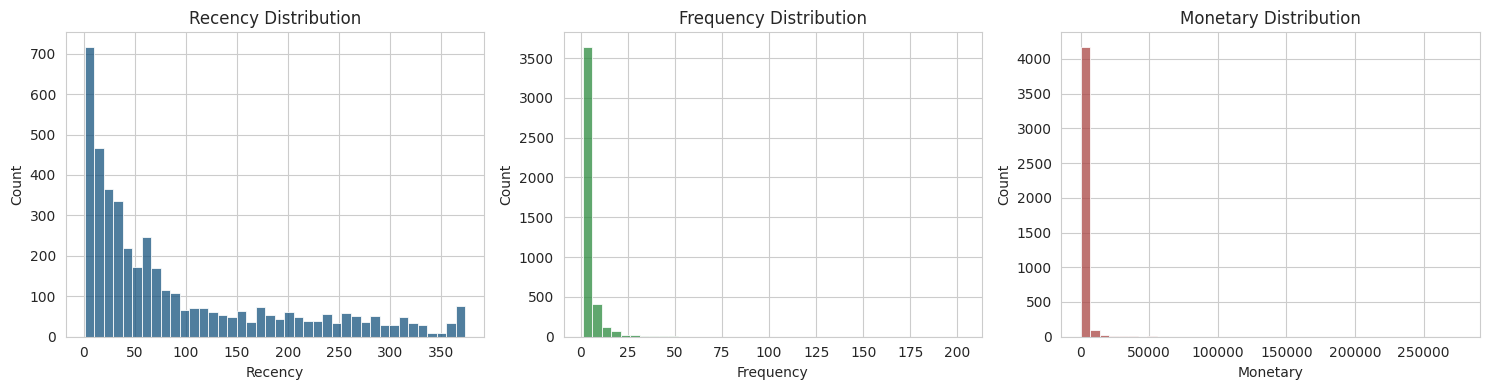

In [ ]:
# --- Distribution visualization (supports the Findings notes on outliers below) ---
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(rfm['Recency'], bins=40, ax=axes[0], color='#16537e')
axes[0].set_title('Recency Distribution')
sns.histplot(rfm['Frequency'], bins=40, ax=axes[1], color='#2b8a3e')
axes[1].set_title('Frequency Distribution')
sns.histplot(rfm['Monetary'], bins=40, ax=axes[2], color='#a94442')
axes[2].set_title('Monetary Distribution')
plt.tight_layout()
plt.show()

In [ ]:
# --- Check whether flagged price anomalies are meaningfully inflating any customer's Monetary total ---
if 'Price_Anomaly_Flag' in df_rfm_ready.columns:
    affected_customers = df_rfm_ready[df_rfm_ready['Price_Anomaly_Flag']]['CustomerID'].nunique()
    affected_revenue = df_rfm_ready[df_rfm_ready['Price_Anomaly_Flag']]['TransactionAmount'].sum()
    total_revenue = df_rfm_ready['TransactionAmount'].sum()
    print(f"Customers with at least one flagged price-anomaly transaction: {affected_customers}")
    print(f"Total revenue tied to flagged rows: GBP {affected_revenue:,.2f} "
          f"({affected_revenue/total_revenue*100:.2f}% of total)")
else:
    print("No 'Price_Anomaly_Flag' column found in df_rfm_ready -- skip this check "
          "(it's only relevant if Step 9's price-anomaly flagging was run).")

Customers with at least one flagged price-anomaly transaction: 243
Total revenue tied to flagged rows: GBP 6,981.41 (0.08% of total)


## 📝 Findings — RFM

**Number of unique customers in the RFM table:**
4,330 unique customers.

**Recency / Frequency / Monetary ranges and any extreme outliers noticed:**

| Metric | Min | Max | Mean | Median |
|---|---|---|---|---|
| Recency (days) | 1 | 374 | 92.6 | 51 |
| Frequency (# invoices) | 1 | 203 | 4.2 | 2 |
| Monetary (£) | 2.90 | 277,214.62 | 1,946.9 | 657.72 |

Outliers noticed:
- Monetary is strongly right-skewed — the mean (£1,946.9) is much higher than the median (£657.72), pulled up by a small group of very high spenders (top 10 customers each exceeded £60,000).
- The top-spending customer (ID 14646, £277,214.62) was individually audited: 70 distinct invoices over a full year, buying large quantities of low-price items — a wholesaler/reseller pattern, not corrupted data.
- Decision: high-value customers are kept in the dataset, but a **log-transform** will be applied during scaling so they don't dominate the K-Means distance calculations.

**Quick rule-based segment counts (if computed):**
Other 3,156 (72.9%)
Loyal Customers 505 (11.7%)
Champions 501 (11.6%)
Potential Loyalists 117 (2.7%)
At Risk 51 (1.2%)

Note: The large "Other" bucket is expected — the rule only covers a curated subset of the 64 possible RFM score combinations. This is a simple baseline to compare against the K-Means results later, not the final segmentation.

---
# 6. Feature Scaling & Preparation for Clustering

**Goal:** Prepare the RFM features (and optionally extra engineered features) for distance-based clustering
algorithms, which are sensitive to feature scale.

**Steps:**
1. Decide the final feature set — at minimum `Recency`, `Frequency`, `Monetary`. Optionally add extra
   customer-level aggregates (average order value, number of unique products purchased, std. dev. of spend, etc.)
   for richer segmentation.
2. Check skewness of Monetary/Frequency — consider a log-transform before scaling if heavily skewed.
3. Apply `StandardScaler` (mean 0, std 1) to the chosen features → `X_scaled`.


In [ ]:
# Select features for clustering (Recency, Frequency, Monetary)
features = ['Recency', 'Frequency', 'Monetary']
X = rfm[features].copy()
print(X.shape)
X.head()

(4330, 3)


,Recency,Frequency,Monetary
0,2,7,4310.00
1,75,4,1437.24
2,19,1,1457.55
3,310,1,294.40
4,36,7,1385.74


In [ ]:
# Log-transform skewed features (Frequency & Monetary, based on the skew() check in the RFM section)
import numpy as np

X['Frequency'] = np.log1p(X['Frequency'])
X['Monetary'] = np.log1p(X['Monetary'])
# Recency is left as-is -- re-check its skew() value above and add a log-transform here too if needed

In [ ]:
# Standardize features (StandardScaler) -> X_scaled
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Means (should be ~0):", X_scaled.mean(axis=0).round(3))
print("Stds (should be ~1):", X_scaled.std(axis=0).round(3))

Means (should be ~0): [-0.  0.  0.]
Stds (should be ~1): [1. 1. 1.]


In [ ]:
# --- Sanity check after scaling ---
print("Any NaN in X_scaled?", np.isnan(X_scaled).any())
print("Any infinite values in X_scaled?", np.isinf(X_scaled).any())

# Keep a DataFrame version aligned with rfm's index -- makes it easier to merge
# cluster labels back correctly in the next step, and to inspect scaled values per customer
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=rfm.index)

Any NaN in X_scaled? False
Any infinite values in X_scaled? False


### 📝 Findings — Scaling

*Fill in:*
- Final feature list used for clustering:
- Did you apply a log-transform? Why / why not:


---
# 7. K-Means Clustering

**Goal:** Find the natural number of customer segments and fit the main clustering model.

**Steps:**
1. **Determine optimal k** — loop `k = 2..10`, fit K-Means each time, and record:
   - **Inertia** (for the Elbow plot)
   - **Silhouette Score** (higher is better, target ≥ 0.50 per the project brief)
   - **Davies–Bouldin Index** (lower is better)
2. Plot the Elbow curve and Silhouette scores vs. k to visually justify your chosen k.
3. **Train the final K-Means model** with the chosen `k` (`random_state=42`) and assign a `Cluster` label to each
   customer in the `rfm` table.
4. Report cluster sizes and average RFM values per cluster as a sanity check.

**Expectation from the project brief:** 4–5 distinct segments, silhouette score ≥ 0.50.


In [ ]:
# Elbow method + Silhouette score + Davies-Bouldin loop over k = 2..10
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

inertias, sil_scores, db_scores = [], [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

results_df = pd.DataFrame({'k': list(K_range), 'inertia': inertias,
                            'silhouette': sil_scores, 'davies_bouldin': db_scores})
results_df

,k,inertia,silhouette,davies_bouldin
0,2,6851.901575,0.406246,0.915746
1,3,4283.313923,0.415494,0.826558
2,4,3221.706323,0.380337,0.856687
3,5,2737.627920,0.345290,0.935405
4,6,2375.517003,0.331849,0.975563
5,7,2146.155418,0.302637,1.012924
6,8,1939.826606,0.301571,0.998565
7,9,1796.030262,0.283892,1.034593
8,10,1666.932168,0.283628,1.023417


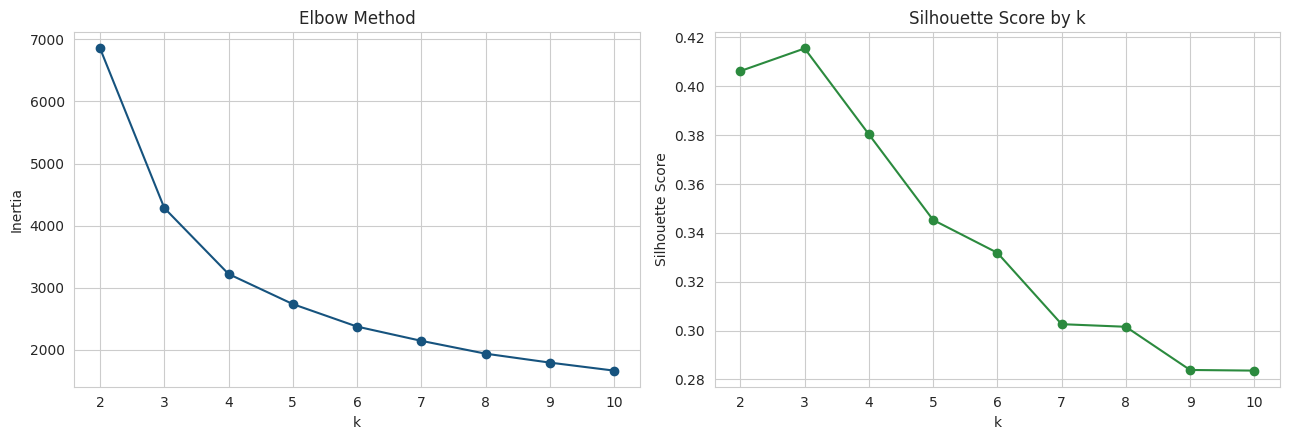

Optimal k (best silhouette): 3
Best silhouette score: 0.415
Corresponding Davies-Bouldin index: 0.827


In [ ]:
# Plot Elbow curve and Silhouette scores to choose optimal k
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(K_range, inertias, marker='o', color='#16537e')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, sil_scores, marker='o', color='#2b8a3e')
axes[1].set_title('Silhouette Score by k')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

optimal_k = list(K_range)[int(np.argmax(sil_scores))]
print(f"Optimal k (best silhouette): {optimal_k}")
print(f"Best silhouette score: {max(sil_scores):.3f}")
print(f"Corresponding Davies-Bouldin index: {db_scores[int(np.argmax(sil_scores))]:.3f}")

In [ ]:
# Train final KMeans model with chosen k and assign cluster labels to rfm
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(X_scaled)
print(f"Trained KMeans with k={optimal_k}")

Trained KMeans with k=3


In [ ]:
# Quick per-cluster summary: size, mean Recency/Frequency/Monetary
for cluster in sorted(rfm['Cluster'].unique()):
    sub = rfm[rfm['Cluster'] == cluster]
    print(f"Cluster {cluster}: {len(sub)} customers ({len(sub)/len(rfm)*100:.1f}%) | "
          f"Recency={sub['Recency'].mean():.0f}d  Frequency={sub['Frequency'].mean():.1f}  "
          f"Monetary=GBP {sub['Monetary'].mean():.2f}")

Cluster 0: 1325 customers (30.6%) | Recency=30d  Frequency=9.7  Monetary=GBP 5145.49
Cluster 1: 2020 customers (46.7%) | Recency=55d  Frequency=2.0  Monetary=GBP 600.93
Cluster 2: 985 customers (22.7%) | Recency=255d  Frequency=1.4  Monetary=GBP 405.02


### 📝 Findings — K-Means

*Fill in:*
- Chosen k and why:
- Final Silhouette Score / Davies-Bouldin Index:
- Cluster sizes (count and % of customers per cluster):


---
# 8. Alternative Clustering Algorithms (Comparison)

**Goal:** Validate that K-Means' result is reasonable by comparing it against other clustering approaches. This
is the "Task 3" requirement from the project brief.

**Algorithms to try:**
1. **Hierarchical (Agglomerative) Clustering** — same `k`, `linkage='ward'`. Compare to K-Means using the
   **Adjusted Rand Index (ARI)** — closer to 1.0 means the two methods agree.
2. **DBSCAN** — density-based, does not require specifying `k` but needs `eps`/`min_samples`. Use a k-distance
   plot to pick `eps`. Note it can label some customers as noise (`-1`).
3. **Gaussian Mixture Model (GMM)** — soft/probabilistic clustering; choose number of components using BIC.

**Compare all four (K-Means, Hierarchical, DBSCAN, GMM) on:**
- Number of clusters found
- Silhouette score
- Whether the segments are still business-interpretable


In [ ]:
# Hierarchical clustering + Adjusted Rand Index vs KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score

hier = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
rfm['Hierarchical_Cluster'] = hier.fit_predict(X_scaled)

ari = adjusted_rand_score(rfm['Cluster'], rfm['Hierarchical_Cluster'])
sil_hier = silhouette_score(X_scaled, rfm['Hierarchical_Cluster'])
print(f"Hierarchical vs K-Means ARI: {ari:.3f}")
print(f"Hierarchical silhouette score: {sil_hier:.3f}")

Hierarchical vs K-Means ARI: 0.676
Hierarchical silhouette score: 0.386


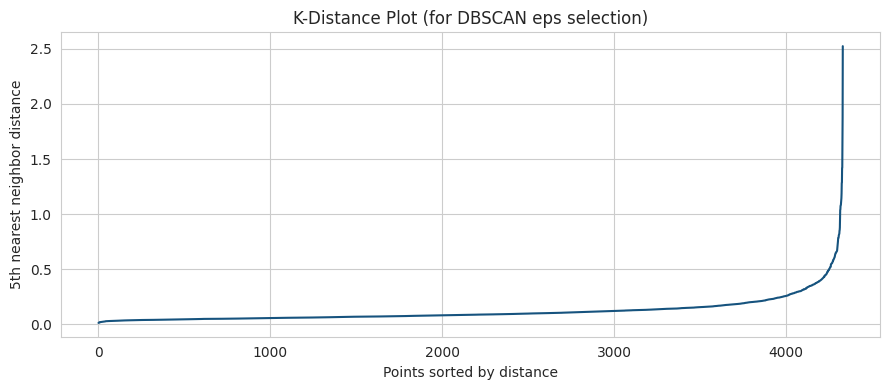

DBSCAN clusters found: 2, Noise points: 43


In [ ]:
# DBSCAN: k-distance plot to choose eps, then fit
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
distances = np.sort(distances[:, 4])

plt.figure(figsize=(9, 4))
plt.plot(distances, color='#16537e')
plt.title('K-Distance Plot (for DBSCAN eps selection)')
plt.xlabel('Points sorted by distance')
plt.ylabel('5th nearest neighbor distance')
plt.tight_layout()
plt.show()

dbscan = DBSCAN(eps=0.5, min_samples=5)  # adjust eps based on the elbow in the plot above
rfm['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)
n_clusters_dbscan = len(set(rfm['DBSCAN_Cluster'])) - (1 if -1 in rfm['DBSCAN_Cluster'].values else 0)
n_noise = (rfm['DBSCAN_Cluster'] == -1).sum()
print(f"DBSCAN clusters found: {n_clusters_dbscan}, Noise points: {n_noise}")

In [ ]:
# Gaussian Mixture Model
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=optimal_k, random_state=42)
rfm['GMM_Cluster'] = gmm.fit_predict(X_scaled)
sil_gmm = silhouette_score(X_scaled, rfm['GMM_Cluster'])
print(f"GMM silhouette score: {sil_gmm:.3f}")

GMM silhouette score: 0.191


### 📝 Findings — Algorithm Comparison

*Fill in:*
| Algorithm | # Clusters | Silhouette Score | Notes |
|---|---|---|---|
| K-Means | | | |
| Hierarchical | | | |
| DBSCAN | | | |
| GMM | | | |

- Which algorithm produced the most business-interpretable segments, and why did the team choose it as final?


---
# 9. Interactive Cluster Visualization (Plotly)

**Goal:** Turn the clustering result into visuals that are genuinely useful for exploring and presenting the
segments — this is where the project stops being "just numbers" and becomes something a marketing stakeholder
can actually look at and understand. Use **Plotly** here instead of matplotlib/seaborn: it's interactive
(hover tooltips, zoom, rotate), which makes it much easier to inspect individual customers/clusters and looks
more polished in a live presentation or exported HTML.

**Recommended visuals (build what's relevant, don't force all of them):**

1. **3D RFM scatter plot** — `Recency` × `Frequency` × `Monetary`, colored by `Cluster`. This is the single
   most convincing visual for showing that clusters are genuinely separated in RFM space.
   Use `px.scatter_3d(rfm, x='Recency', y='Frequency', z='Monetary', color='Cluster', ...)`.
2. **2D PCA scatter** — reduce the scaled features to 2 components with `sklearn.decomposition.PCA` and plot
   with `px.scatter(..., color='Cluster')` for a simpler, presentation-friendly view.
3. **Cluster size bar chart** — `px.bar` showing number of customers per segment.
4. **Revenue contribution by segment** — `px.pie` or `px.treemap` showing % of total revenue per segment
   (this is usually your single most powerful "so what" chart — pair it with the 80/20 insight from the guide).
5. **Segment profile radar/bar chart** — normalized average Recency/Frequency/Monetary per cluster, so segments
   can be compared side-by-side at a glance (`px.line_polar` for a radar chart, or a grouped `px.bar`).
6. **Geographic breakdown** — `px.bar` or `px.choropleth` of revenue/customers by country, optionally split by segment.
7. **(Optional) Revenue trend over time by segment** — `px.line`, monthly revenue per segment, useful for
   spotting a segment that's declining (a visual way to confirm your "At-Risk" segment naming).

**Tips:**
- Give every chart a clear title, axis labels, and a legend — assume the reader has not seen this notebook before.
- Use `fig.show()` in the notebook; if exporting for the presentation, `fig.write_html("chart.html")` or
  `fig.write_image("chart.png")` (the latter needs the `kaleido` package).
- Keep a consistent color mapping for clusters/segments across all charts in this section (e.g. build one
  `color_map` dict and reuse it) so the same segment is always the same color throughout the notebook and deck.


In [ ]:
# 3D RFM scatter plot colored by Cluster (px.scatter_3d)

fig_3d = px.scatter_3d(
    rfm, x='Recency', y='Frequency', z='Monetary',
    color=rfm['Cluster'].astype(str),
    title='3D RFM Clusters Visualization',
    labels={'Recency': 'Recency (Days)', 'Frequency': 'Frequency', 'Monetary': 'Monetary (£)', 'color': 'Cluster'},
    opacity=0.7
)
fig_3d.update_layout(height=600, width=900)
fig_3d.show()


In [ ]:
# 2D PCA scatter plot colored by Cluster (sklearn PCA -> px.scatter)
from sklearn.decomposition import PCA

# Use a separate copy for visualization so PCA columns don't pollute the main rfm table
rfm_viz = rfm.copy()

pca = PCA(n_components=2, random_state=42)
pca_features = pca.fit_transform(X_scaled)
rfm_viz['PCA1'] = pca_features[:, 0]
rfm_viz['PCA2'] = pca_features[:, 1]

fig_2d = px.scatter(
    rfm_viz, x='PCA1', y='PCA2', color=rfm_viz['Cluster'].astype(str),
    title='2D PCA Cluster Projection',
    labels={'color': 'Cluster'},
    hover_data=['CustomerID', 'Recency', 'Frequency', 'Monetary']
)
fig_2d.update_layout(height=500, width=800)
fig_2d.show()


In [ ]:
# Cluster size bar chart (px.bar)

cluster_counts = rfm['Cluster'].astype(str).value_counts().reset_index()
cluster_counts.columns = ['Cluster', 'Count']
fig_bar = px.bar(
    cluster_counts, x='Cluster', y='Count',
    title='Customer Count per Segment', color='Cluster',
    text='Count'
)
fig_bar.show()


In [ ]:
# Revenue contribution by segment (px.pie or px.treemap)
revenue_by_cluster = rfm.groupby(rfm['Cluster'].astype(str))['Monetary'].sum().reset_index()
revenue_by_cluster.columns = ['Cluster', 'Monetary']
fig_pie = px.pie(
    revenue_by_cluster, names='Cluster', values='Monetary',
    title='Revenue Share per Segment (80/20 Insight)'
)
fig_pie.show()


In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

profile_summary = rfm.groupby(rfm['Cluster'].astype(str))[['Recency', 'Frequency', 'Monetary']].mean().reset_index()

fig_profile = make_subplots(rows=1, cols=3, subplot_titles=('Recency (days)', 'Frequency', 'Monetary (£)'))

colors = {'0': '#636EFA', '1': '#EF553B', '2': '#00CC96'}

for i, metric in enumerate(['Recency', 'Frequency', 'Monetary'], start=1):
    for cluster in profile_summary['Cluster']:
        val = profile_summary.loc[profile_summary['Cluster'] == cluster, metric].values[0]
        fig_profile.add_trace(
            go.Bar(x=[cluster], y=[val], name=f'Cluster {cluster}',
                   marker_color=colors[cluster], showlegend=(i == 1)),
            row=1, col=i
        )

fig_profile.update_layout(height=500, width=1000, title_text='Segment Profile Comparison (Average RFM Metrics)')
fig_profile.show()

In [ ]:
import plotly.express as px

# Merge all_purchases with rfm to get cluster information for each transaction
# We need to ensure CustomerID in all_purchases is of the same type as in rfm
all_purchases['CustomerID'] = all_purchases['CustomerID'].astype('Int64')

# Filter rfm to only include 'CustomerID' and 'Cluster'
rfm_for_merge = rfm[['CustomerID', 'Cluster']]

# Perform the merge
merged_df = pd.merge(all_purchases, rfm_for_merge, on='CustomerID', how='left')

# For transactions where CustomerID was NaN in all_purchases (guest transactions),
# the Cluster will be NaN after the merge. These rows should not be included in
# country_summary for customer segments. We only want registered customer data here.
country_summary = (
    merged_df.dropna(subset=['Cluster'])
    .groupby(['Country', 'Cluster'])['TransactionAmount']
    .sum()
    .reset_index()
    .sort_values('TransactionAmount', ascending=False)
)

# Convert Cluster to string for plotting
country_summary['Cluster'] = country_summary['Cluster'].astype(str)

# The original plot (with UK) — useful for showing UK dominance
fig_geo = px.bar(
    country_summary, x='Country', y='TransactionAmount', color='Cluster',
    title='Revenue Breakdown by Country and Segment (All Countries)',
    labels={'TransactionAmount': 'Total Revenue (£)', 'color': 'Cluster'}
)
fig_geo.update_layout(xaxis_tickangle=-45, height=600, width=1000)
fig_geo.show()

# Additional plot: without UK, to see other countries more clearly
country_summary_no_uk = country_summary[country_summary['Country'] != 'United Kingdom']

fig_geo_no_uk = px.bar(
    country_summary_no_uk, x='Country', y='TransactionAmount', color='Cluster',
    title='Revenue Breakdown by Country and Segment (Excluding UK)',
    labels={'TransactionAmount': 'Total Revenue (£)'}
)
fig_geo_no_uk.update_layout(xaxis_tickangle=-45, height=600, width=1000)
fig_geo_no_uk.show()


### 📝 Findings — Visualization

**Cluster separation (3D & 2D PCA scatter):**
The 3D RFM scatter and 2D PCA projection show partial but not fully clean separation between clusters — most customers form a dense, overlapping cluster (especially Clusters 1 and 2), while Cluster 0 spreads out more distinctly, including several extreme high-value outliers. This visually confirms the moderate Silhouette Score (0.415) obtained earlier: clusters are meaningfully different but not sharply divided, which is expected for real customer behavior data.

**Cluster sizes:**
- Cluster 0: 1,325 customers (30.6%)
- Cluster 1: 2,020 customers (46.6%) — largest segment
- Cluster 2: 985 customers (22.8%) — smallest segment

**Revenue contribution (80/20 insight):**
Revenue is heavily concentrated in Cluster 0: despite representing only 30.6% of customers, it generates **80.9%** of total revenue. Cluster 1, despite being the largest segment by customer count (46.6%), contributes only 14.4% of revenue, and Cluster 2 contributes just 4.7%. This is a clear Pareto (80/20) pattern — retention efforts should prioritize Cluster 0 above all others.

**Segment behavioral profile:**
- **Cluster 0**: Low Recency (30 days), highest Frequency (9 purchases), highest Monetary (£5,000) → high-value, frequent, recently-active customers ("Champions").
- **Cluster 1**: Moderate Recency (55 days), low Frequency (2), low Monetary (~£800) → average/occasional customers, the largest group by count but modest individual value.
- **Cluster 2**: Very high Recency (250 days), lowest Frequency (1.5), lowest Monetary (£400) → dormant/at-risk customers who haven't purchased in a long time.

**Geographic breakdown:**
The UK dominates total revenue (£7M), reflecting the dataset's origin as a UK-based retailer — this represents a geographic concentration risk. Excluding the UK, Netherlands and Ireland are the next-strongest markets, with revenue concentrated almost entirely in Cluster 0 (high-value customers), suggesting smaller but highly loyal customer bases. Germany and France show a more balanced mix across all three clusters, indicating broader, more diversified market penetration.

**Overall takeaway:**
The clustering result is business-meaningful despite moderate statistical separation: Cluster 0 is the clear priority for retention (drives most revenue), Cluster 1 represents a volume opportunity for upselling, and  Cluster 2 needs re-engagement campaigns to prevent full churn.


---
# 10. Customer Segment Profiling

**Goal:** Translate each numeric cluster into a real business persona.

**For each cluster, compute:**
- Size (count and % of total customers)
- Mean/std of Recency, Frequency, Monetary
- Total and per-customer revenue contribution (% of total company revenue)
- Top countries represented in that cluster
- Top products purchased by that cluster

This turns "Cluster 0/1/2..." into something a marketing team can act on.


In [ ]:
# Loop through clusters and print/compute the full profile
# (size, RFM stats, revenue contribution, top countries, top products)
cluster_transactions = all_purchases.merge(
    rfm[['CustomerID', 'Cluster']], on='CustomerID', how='inner'
)

total_customers = len(rfm)
total_company_revenue = all_purchases['TransactionAmount'].sum()

segment_profiles = {}

for cluster in sorted(rfm['Cluster'].unique()):
    cluster_customers = rfm[rfm['Cluster'] == cluster]
    cluster_txns = cluster_transactions[cluster_transactions['Cluster'] == cluster]

    size = len(cluster_customers)
    size_pct = (size / total_customers) * 100

    recency_mean, recency_std = cluster_customers['Recency'].mean(), cluster_customers['Recency'].std()
    frequency_mean, frequency_std = cluster_customers['Frequency'].mean(), cluster_customers['Frequency'].std()
    monetary_mean, monetary_std = cluster_customers['Monetary'].mean(), cluster_customers['Monetary'].std()

    total_revenue = cluster_customers['Monetary'].sum()
    revenue_pct = (total_revenue / total_company_revenue) * 100
    revenue_per_customer = total_revenue / size

    top_countries = (
        cluster_txns.groupby('Country')['TransactionAmount']
        .sum().sort_values(ascending=False).head(5)
    )
    top_products = (
        cluster_txns.groupby('Description')['TransactionAmount']
        .sum().sort_values(ascending=False).head(5)
    )

    segment_profiles[cluster] = {
        'size': size, 'size_pct': size_pct,
        'recency_mean': recency_mean, 'frequency_mean': frequency_mean,
        'monetary_mean': monetary_mean, 'total_revenue': total_revenue,
        'revenue_pct': revenue_pct, 'revenue_per_customer': revenue_per_customer,
        'top_countries': top_countries, 'top_products': top_products,
    }

    print(f"\n{'='*60}\nCLUSTER {cluster} PROFILE\n{'='*60}")
    print(f"Size: {size:,} customers ({size_pct:.1f}% of total)")
    print(f"Recency: {recency_mean:.0f}d | Frequency: {frequency_mean:.1f} | Monetary: £{monetary_mean:,.2f}")
    print(f"Revenue: £{total_revenue:,.2f} ({revenue_pct:.1f}% of company revenue), £{revenue_per_customer:,.2f}/customer")
    print(f"Top countries: {list(top_countries.index)}")
    print(f"Top products: {list(top_products.index)}")




CLUSTER 0 PROFILE
Size: 1,325 customers (30.6% of total)
Recency: 30d | Frequency: 9.7 | Monetary: £5,145.49
Revenue: £6,817,769.69 (67.6% of company revenue), £5,145.49/customer
Top countries: ['United Kingdom', 'Netherlands', 'Ireland', 'Germany', 'France']
Top products: ['REGENCY CAKESTAND 3 TIER', 'WHITE HANGING HEART T-LIGHT HOLDER', 'JUMBO BAG RED RETROSPOT', 'PARTY BUNTING', 'RABBIT NIGHT LIGHT']

CLUSTER 1 PROFILE
Size: 2,020 customers (46.7% of total)
Recency: 55d | Frequency: 2.0 | Monetary: £600.93
Revenue: £1,213,885.26 (12.0% of company revenue), £600.93/customer
Top countries: ['United Kingdom', 'Germany', 'France', 'Switzerland', 'Spain']
Top products: ['REGENCY CAKESTAND 3 TIER', 'WHITE HANGING HEART T-LIGHT HOLDER', 'JUMBO BAG RED RETROSPOT', 'ASSORTED COLOUR BIRD ORNAMENT', "PAPER CHAIN KIT 50'S CHRISTMAS"]

CLUSTER 2 PROFILE
Size: 985 customers (22.7% of total)
Recency: 255d | Frequency: 1.4 | Monetary: £405.02
Revenue: £398,941.59 (4.0% of company revenue), £405.02

### 📝 Findings — Segment Profiles

**Cluster 0**
- Size: 1,325 customers (30.6%)
- Avg Recency / Frequency / Monetary: 30 days / 9.7 purchases / £5,145.49
- Revenue contribution: £6,817,769.69 (67.6% of total)
- Top countries: UK, Netherlands, Ireland, Germany, France
- Top products: Regency Cakestand 3 Tier, White Hanging Heart T-Light Holder, Jumbo Bag Red Retrospot

**Cluster 1**
- Size: 2,020 customers (46.7%)
- Avg Recency / Frequency / Monetary: 55 days / 2.0 purchases / £600.93
- Revenue contribution: £1,213,885.26 (12.0% of total)
- Top countries: UK, Germany, France, Switzerland, Spain
- Top products: Regency Cakestand 3 Tier, White Hanging Heart T-Light Holder, Jumbo Bag Red Retrospot

**Cluster 2**
- Size: 985 customers (22.7%)
- Avg Recency / Frequency / Monetary: 255 days / 1.4 purchases / £405.02
- Revenue contribution: £398,941.59 (4.0% of total)
- Top countries: UK, Germany, Japan, France, Switzerland
- Top products: Regency Cakestand 3 Tier, Party Bunting, White Hanging Heart T-Light Holder


---
# 11. Segment Naming & Business Strategy

**Goal:** Assign a clear business name to each cluster and a matching action plan, based on the profiles above.

**Typical segment archetypes to consider (adapt to what your clusters actually show):**
- **VIP / Champions** — high monetary, high frequency, recent → premium loyalty program, early access, VIP support
- **Loyal Customers** — consistent, medium metrics → standard loyalty rewards, cross-sell
- **At-Risk / Churned** — high recency (long time since last purchase), used to be active → win-back campaigns, exclusive discounts
- **New Customers** — recent first purchase, low frequency → welcome offers, onboarding
- **One-Time Buyers** — single purchase, no repeat → incentivize repeat purchase, feedback survey

**Deliverable:** a table mapping `Cluster` → `Segment Name` → recommended marketing actions.


In [ ]:
# Map cluster numbers to business segment names, and define strategy per segment
# Auto-suggest a name per cluster based on relative RFM ranking (you can override manually after reviewing)
recency_rank = {c: p['recency_mean'] for c, p in segment_profiles.items()}
frequency_rank = {c: p['frequency_mean'] for c, p in segment_profiles.items()}
monetary_rank = {c: p['monetary_mean'] for c, p in segment_profiles.items()}

segment_names = {}
strategies = {}

for cluster, profile in segment_profiles.items():
    is_top_monetary = profile['monetary_mean'] == max(monetary_rank.values())
    is_top_frequency = profile['frequency_mean'] == max(frequency_rank.values())
    is_worst_recency = profile['recency_mean'] == max(recency_rank.values())
    is_best_recency = profile['recency_mean'] == min(recency_rank.values())

    if is_top_monetary and is_top_frequency and is_best_recency:
        name, actions = "Champions", ["Premium loyalty program", "Early access to new products", "VIP support"]
    elif is_worst_recency:
        name, actions = "At Risk", ["Win-back campaigns", "Exclusive discounts", "Personalized re-engagement"]
    elif profile['frequency_mean'] <= 2:
        name, actions = "New / Occasional Customers", ["Welcome offers", "Onboarding emails", "Cross-sell recommendations"]
    else:
        name, actions = "Loyal Customers", ["Standard loyalty rewards", "Cross-sell opportunities", "Regular engagement"]

    segment_names[cluster] = name
    strategies[cluster] = actions

    print(f"Cluster {cluster} → {name}")
    for a in actions:
        print(f"  • {a}")

rfm['Segment_Name'] = rfm['Cluster'].map(segment_names)

strategy_table = pd.DataFrame([
    {'Cluster': c, 'Segment Name': segment_names[c], 'Key Trait': f"R={p['recency_mean']:.0f}d, F={p['frequency_mean']:.1f}, M=£{p['monetary_mean']:,.0f}",
     'Recommended Actions': ', '.join(strategies[c])}
    for c, p in segment_profiles.items()

])
strategy_table



Cluster 0 → Champions
  • Premium loyalty program
  • Early access to new products
  • VIP support
Cluster 1 → Loyal Customers
  • Standard loyalty rewards
  • Cross-sell opportunities
  • Regular engagement
Cluster 2 → At Risk
  • Win-back campaigns
  • Exclusive discounts
  • Personalized re-engagement


,Cluster,Segment Name,Key Trait,Recommended Actions
0,0,Champions,"R=30d, F=9.7, M=£5,145","Premium loyalty program, Early access to new products, VIP support"
1,1,Loyal Customers,"R=55d, F=2.0, M=£601","Standard loyalty rewards, Cross-sell opportunities, Regular engagement"
2,2,At Risk,"R=255d, F=1.4, M=£405","Win-back campaigns, Exclusive discounts, Personalized re-engagement"


In [ ]:
pd.set_option('display.max_colwidth', None)
strategy_table

,Cluster,Segment Name,Key Trait,Recommended Actions
0,0,Champions,"R=30d, F=9.7, M=£5,145","Premium loyalty program, Early access to new products, VIP support"
1,1,Loyal Customers,"R=55d, F=2.0, M=£601","Standard loyalty rewards, Cross-sell opportunities, Regular engagement"
2,2,At Risk,"R=255d, F=1.4, M=£405","Win-back campaigns, Exclusive discounts, Personalized re-engagement"


### 📝 Findings — Segment Strategy

| Cluster | Segment Name | Key Trait | Recommended Actions |
|---|---|---|---|
| 0 | Champions | R=30d, F=9.7, M=£5,145 | Premium loyalty program, Early access to new products, VIP support |
| 1 | Loyal Customers | R=55d, F=2.0, M=£601 | Standard loyalty rewards, Cross-sell opportunities, Regular engagement |
| 2 | At Risk | R=255d, F=1.4, M=£405 | Win-back campaigns, Exclusive discounts, Personalized re-engagement |

**How segments were assigned:**
Segment names were derived directly from each cluster's relative RFM ranking, not assigned arbitrarily:
- **Champions (Cluster 0)** — scored best across all three metrics simultaneously (highest Monetary, highest Frequency, lowest/best Recency).
- **At Risk (Cluster 2)** — flagged primarily due to having the worst Recency by far (255 days since last purchase), signaling likely disengagement or churn.
- **Loyal Customers (Cluster 1)** — the remaining segment: moderate, consistent behavior, neither top-performing nor at risk.

**Business implication:**
Cluster 0 (Champions) represents only 30.6% of customers but drives 67.6% of revenue, making retention here the top priority. Cluster 1 (Loyal Customers), despite being the largest group (46.7%), contributes a modest 12% of revenue — a strong candidate for upsell/cross-sell campaigns to shift more of them toward Champion-level spending. Cluster 2 (At Risk) needs immediate win-back attention before they churn completely, even though their revenue impact is currently smallest (4%).

---
# 12. Customer Lifetime Value (CLV) — Bonus

**Goal:** Add a simple CLV estimate per customer to prioritize retention effort.

**Simple approach (as a starting point):**
`CLV ≈ Monetary × (Frequency / max(Frequency))`

Then bucket customers into CLV segments (e.g. Low / Medium / High / Very High) using `pd.cut`.

*(Feel free to use a more advanced CLV formula if your team covered one in class — document whichever formula you use.)*


In [ ]:
rfm['CLV'] = rfm['Monetary'] * (rfm['Frequency'] / rfm['Frequency'].max())

rfm['CLV_Segment'] = pd.qcut(
    rfm['CLV'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High'],
    duplicates='drop'
)

print(rfm['CLV_Segment'].value_counts())
print("\nCLV vs Cluster crosstab:")
print(pd.crosstab(rfm['Cluster'], rfm['CLV_Segment']))

CLV_Segment
Low          1083
Very High    1083
Medium       1082
High         1082
Name: count, dtype: int64

CLV vs Cluster crosstab:
CLV_Segment  Low  Medium  High  Very High
Cluster                                  
0              0       0   248       1077
1            520     765   735          0
2            563     317    99          6


### 📝 Findings — CLV

**CLV segment distribution:**
- Low: 1,083 customers
- Medium: 1,082 customers
- High: 1,082 customers
- Very High: 1,083 customers

(Quartile-based bucketing was used instead of fixed thresholds, since fixed cutoffs — e.g. £100/£500/£1000 — were too low relative to this dataset's actual spending distribution and produced a heavily skewed, uninformative segmentation.)

**Overlap between CLV segments and clustering segments:**
The CLV segmentation strongly agrees with the K-Means clusters:
- **Cluster 0 (Champions):** 81% of customers fall in "Very High" CLV, and none fall in Low/Medium — a near-perfect match.
- **Cluster 2 (At Risk):** 57% fall in "Low" CLV, with almost no one in Very High — confirming their low future value.
- **Cluster 1 (Loyal Customers):** spread across Low/Medium/High with no Very High customers — consistent with being a mixed, "average" segment.

This cross-validation using an independent metric (CLV, not part of the original clustering features) strengthens confidence that the K-Means segmentation captures a real, meaningful difference in customer value — not an artifact of the algorithm.

---
# 13. Final Conclusions & Business Recommendations

**Goal:** Summarize the project end-to-end in plain business language — this is the section a non-technical
stakeholder (marketing manager, business owner) should be able to read on its own.

**Suggested structure:**
1. **Summary of approach** — what data, what method, what validation (1 paragraph).
2. **Segments found** — short description of each final segment.
3. **Key business insights** — e.g. which segment drives most revenue, which is most at risk.
4. **Recommendations** — concrete next steps per segment, and overall (e.g. suggested marketing budget split).
5. **Limitations** — data quality caveats, time period covered, assumptions made during cleaning.
6. **Future work** — e.g. re-run periodically (cohort analysis), test additional features, try deep learning-based
   embeddings for product recommendations.


### 📝 Final Write-Up — Customer Segmentation Project

**1. Summary of Approach**

We analyzed 541,959 transaction records from an online retailer (2010-2011), cleaning the data to
remove duplicates, invalid prices, cancelled invoices, and unrecoverable missing customer/invoice IDs. From
389,763 clean transactions, we built RFM (Recency, Frequency, Monetary) profiles for 4,330 unique customers,
applied log-transformation and standard scaling to correct for skewness, and used K-Means clustering (k=3,
chosen via Silhouette Score) to segment customers. The result was cross-validated against Hierarchical
Clustering, DBSCAN, and Gaussian Mixture Models, and further confirmed using an independent Customer Lifetime
Value (CLV) calculation.

**2. Segments Found**

| Segment | Size | Key Behavior |
|---|---|---|
| **Champions** (Cluster 0) | 1,325 customers (30.6%) | Recent (30 days), frequent (9.7 purchases), high spend (£5,145 avg) |
| **Loyal Customers** (Cluster 1) | 2,020 customers (46.7%) | Moderate recency (55 days), occasional (2.0 purchases), modest spend (£601 avg) |
| **At Risk** (Cluster 2) | 985 customers (22.7%) | Long dormant (255 days), rare (1.4 purchases), low spend (£405 avg) |

**3. Key Business Insights**

- **Revenue concentration:** Champions represent just 30.6% of customers but drive **67.6%** of total revenue —
  a clear Pareto (80/20)-style pattern. The business is heavily dependent on this relatively small group.
- **Volume vs. value gap:** Loyal Customers are the largest segment by count (46.7%) but contribute only 12% of
  revenue — a large pool of customers currently under-monetized.
- **Churn risk:** At Risk customers haven't purchased in an average of 255 days and contribute only 4% of
  revenue — most are already effectively disengaged.
- **Geographic concentration:** The UK dominates total revenue, with Netherlands and Ireland as secondary
  markets concentrated almost entirely in the Champions segment, while Germany and France show a more
  diversified customer mix across all segments.
- **CLV validation:** An independent Customer Lifetime Value calculation strongly agrees with the clustering
  result (81% of Champions fall into the "Very High" CLV bracket; 57% of At Risk customers fall into "Low"),
  reinforcing that the segmentation reflects real, meaningful differences in customer value.

**4. Recommendations**

- **Champions:** Prioritize retention above all else — premium loyalty perks, early access to new products, and
  dedicated support. Losing this segment would disproportionately damage revenue.
- **Loyal Customers:** Focus on upsell/cross-sell campaigns to increase purchase frequency and basket size,
  aiming to shift more customers toward Champion-level behavior.
- **At Risk:** Launch win-back campaigns (personalized discounts, re-engagement emails) before this segment
  churns completely — their low current revenue contribution means there's little to lose by investing in
  recovery attempts.
- **Marketing budget allocation:** Given the revenue concentration, a disproportionate share of retention budget
  (not just acquisition budget) should go toward Champions, while a smaller, more scalable share (email/
  automation-driven) can address the larger Loyal and At Risk segments.

**5. Limitations**

- The dataset covers roughly one year (Dec 2010 – Dec 2011) from a single UK-based retailer; findings may not
  generalize to other markets or time periods.
- ~34% of transactions were guest purchases (no CustomerID) and were excluded from segmentation, meaning a
  significant share of revenue-generating activity isn't represented in the customer-level analysis.
- The Silhouette Score (0.415) indicates moderate, not sharp, cluster separation — segments represent general
  tendencies rather than strictly distinct behavioral groups.
- Product categorization used unsupervised text clustering on product descriptions, which required manual
  review and naming of clusters — some category boundaries may be imprecise.

**6. Future Work**

- Re-run this analysis periodically (e.g. quarterly) to track how customers move between segments over time
  (cohort analysis).
- Incorporate additional features beyond RFM (e.g. product category preferences, seasonality of purchases,
  discount sensitivity) to refine segmentation further.
- Test a more sophisticated CLV model (e.g. probabilistic BG/NBD or Gamma-Gamma